<a href="https://colab.research.google.com/github/prakash323/ACO/blob/main/ACOproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Imports and Classifier Initialization**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from joblib import Parallel, delayed
import warnings
import os
from sklearn.feature_selection import mutual_info_classif

warnings.filterwarnings("ignore")

# Define classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB()
}

**Dataset Loading Function**

In [ ]:
def load_dataset(data_source, target_column=None):
    # Handle CSV files
    if isinstance(data_source, str) and data_source.endswith('.csv'):
        df = pd.read_csv(data_source)
        df.columns = df.columns.str.strip()
        if target_column is None:
            target_column = df.columns[-1]
            print(f"Using auto-detected target: '{target_column}'")
        elif target_column not in df.columns:
            raise ValueError(f"Target '{target_column}' not found. Available columns: {list(df.columns)}")

        # Separate features and target
        X = df.drop(columns=[target_column])
        y = df[target_column]
        feature_names = X.columns.tolist()
        dataset_name = os.path.basename(data_source).split('.')[0]

    # Handle sklearn datasets
    elif hasattr(data_source, 'data'):  # sklearn dataset object
        df = pd.DataFrame(data_source.data, columns=data_source.feature_names)
        df['target'] = data_source.target

        # Use sklearn's default target name unless overridden
        target_column = target_column if target_column else 'target'
        X = df.drop(columns=['target'])
        y = df['target']
        feature_names = data_source.feature_names
        dataset_name = data_source.__class__.__name__[5:]  # e.g., "load_wine" → "wine"

    # Handle direct DataFrame input
    elif isinstance(data_source, pd.DataFrame):
        df = data_source.copy()
        if target_column is None:
            target_column = df.columns[-1]
            print(f"Using auto-detected target: '{target_column}'")
        X = df.drop(columns=[target_column])
        y = df[target_column]
        feature_names = X.columns.tolist()
        dataset_name = "custom_dataframe"

    else:
        raise ValueError("Unsupported data source type")

    # Convert to numpy arrays for consistency
    return df, X.values, y.values, feature_names, dataset_name

**Exploratory Data Analysis (EDA) Function**

In [ ]:
def perform_eda(df, dataset_name, target_column):

    print(f"\n Exploratory Data Analysis for {dataset_name}")

    # Dataset info
    print("\nDataset Info:")
    print(df.info())

    # Summary statistics
    print("\nSummary Statistics:")
    print(df.describe())

    # Missing values
    print("\nMissing Values:")
    print(df.isnull().sum())

    # Feature types
    numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    print(f"\nNumerical Features: {len(numerical_cols)}")
    print(f"Categorical Features: {len(categorical_cols)}")

    # Target distribution
    plt.figure(figsize=(8, 6))
    sns.countplot(data=df, x=target_column)
    plt.title(f"Target Distribution - {dataset_name}")
    plt.savefig(f"{dataset_name}_target_distribution.png")
    plt.show()
    print("\n\n")

    # Correlation matrix
    if len(numerical_cols) > 1:
        plt.figure(figsize=(10, 8))
        sns.heatmap(df[numerical_cols].corr(), annot=False, cmap='coolwarm', center=0)
        plt.title(f"Correlation Matrix - {dataset_name}")
        plt.savefig(f"{dataset_name}_correlation_matrix.png")
        plt.show()
        print("\n\n")

    # Feature distributions (for numerical features)
    for col in numerical_cols[:5]:
        plt.figure(figsize=(8, 6))
        sns.histplot(df[col], kde=True)
        plt.title(f"Distribution of {col} - {dataset_name}")
        plt.savefig(f"{dataset_name}_{col}_distribution.png")
        plt.show()
        print("\n\n")

**ACO Feature Selection Functions**

In [ ]:
def compute_heuristic_information(X, y):
    """
    Compute heuristic information for features using mutual information.

    Parameters:
    - X: Feature matrix (n_samples, n_features)
    - y: Target array (n_samples,)

    Returns:
    - heuristic: Array of mutual information scores for each feature
    """
    # Compute mutual information between each feature and the target
    mi_scores = mutual_info_classif(X, y, random_state=42)

    # Normalize to [0, 1] to ensure consistent scaling
    mi_scores = mi_scores / (np.max(mi_scores) + 1e-10)  # Avoid division by zero
    return mi_scores
def evaluate_solution(mask, X_train, y_train, X_test, y_test):
    """
    Evaluate a feature subset using Random Forest Classifier.
    Returns accuracy and feature importances.
    """
    selected = np.where(mask == 1)[0]
    if len(selected) == 0:
        return 0, np.zeros(X_train.shape[1])
    clf = RandomForestClassifier(random_state=42)
    clf.fit(X_train[:, selected], y_train)
    y_pred = clf.predict(X_test[:, selected])
    accuracy = accuracy_score(y_test, y_pred)
    importances = np.zeros(X_train.shape[1])
    importances[selected] = clf.feature_importances_
    return accuracy, importances

def initialize_ants(n_ants, n_features):
    """
    Initialize ants with random binary masks.
    """
    return np.random.randint(2, size=(n_ants, n_features))

def update_pheromone(pheromone, ants, scores, importances, rho, X=None, y=None, Q=1, beta=1.0, min_pheromone=0.1, max_pheromone=10.0):
    """
    Update pheromone levels based on accuracy, feature importances, and heuristic information.

    Parameters:
    - pheromone: Array of pheromone levels (n_features,)
    - ants: Binary masks for ants (n_ants, n_features)
    - scores: Accuracy scores for each ant's feature subset (n_ants,)
    - importances: Feature importances from Random Forest (n_features,)
    - rho: Evaporation rate (float)
    - X: Feature matrix for heuristic computation (n_samples, n_features), optional
    - y: Target array for heuristic computation (n_samples,), optional
    - Q: Scaling factor for pheromone deposits (float, default=1)
    - beta: Weight for heuristic information (float, default=1.0)
    - min_pheromone: Minimum pheromone value (float, default=0.1)
    - max_pheromone: Maximum pheromone value (float, default=10.0)

    Returns:
    - Updated pheromone array
    """
    # Evaporation: Reduce pheromone levels
    pheromone = (1 - rho) * pheromone

    # Compute heuristic information if X and y are provided
    heuristic = compute_heuristic_information(X, y) if X is not None and y is not None else np.ones_like(pheromone)

    # Normalize importances to [0, 1]
    importances = importances / (np.max(importances) + 1e-10)  # Avoid division by zero

    # Reinforcement: Add pheromones based on accuracy, importances, and heuristic
    for i, ant in enumerate(ants):
        # Pheromone deposit = Q * accuracy * ant_mask * (normalized_importance + heuristic)
        deposit = Q * scores[i] * ant * (importances + beta * heuristic)
        pheromone += deposit

    # Clip pheromone values to prevent extreme values
    return np.clip(pheromone, min_pheromone, max_pheromone)

def ant_colony_feature_selection(X_train, y_train, X_test, y_test, n_ants=10, n_iterations=50, rho=0.2, alpha=1, n_jobs=-1):
    n_features = X_train.shape[1]
    pheromone = np.ones(n_features)
    best_score = 0
    best_mask = None
    stagnation_count = 0
    max_stagnation = 10  # Stop if no improvement for 10 iterations

    for iteration in range(n_iterations):
        # Adaptive rho: decrease evaporation as iterations progress
        current_rho = rho * (1 - iteration / n_iterations)

        # Initialize ants
        ants = initialize_ants(n_ants, n_features)

        # Evaluate solutions in parallel
        results = Parallel(n_jobs=n_jobs)(
            delayed(evaluate_solution)(ant, X_train, y_train, X_test, y_test) for ant in ants
        )
        scores = [res[0] for res in results]
        importances = np.mean([res[1] for res in results], axis=0)

        # Update best solution
        for i, score in enumerate(scores):
            if score > best_score:
                best_score = score
                best_mask = ants[i].copy()
                stagnation_count = 0
            else:
                stagnation_count += 1

        # Update pheromone with heuristic information
        pheromone = update_pheromone(
            pheromone, ants, scores, importances, current_rho,
            X=X_train, y=y_train, beta=1.0, min_pheromone=0.1, max_pheromone=10.0
        )

        # Compute probabilities for next iteration
        probabilities = pheromone ** alpha / np.sum(pheromone ** alpha)
        ants = np.array([np.random.rand(n_features) < probabilities for _ in range(n_ants)])

        print(f"Iteration {iteration + 1} | Best Accuracy: {best_score:.4f} | Selected Features: {np.sum(best_mask)}")

        # Early stopping
        if stagnation_count >= max_stagnation:
            print("Early stopping due to stagnation.")
            break

    return best_mask, best_score

**Model Evaluation Function**

In [ ]:
def evaluate_models(X_train, X_test, y_train, y_test, models, dataset_name, selected_features=None):
    print(f"\n📊 Model Evaluation for {dataset_name}")
    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, output_dict=True)
        precision = report['weighted avg']['precision']
        recall = report['weighted avg']['recall']
        f1 = report['weighted avg']['f1-score']

        results.append({
            "Model": name,
            "Accuracy": acc,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1
        })

        # Plot confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap='Blues')
        plt.title(f"Confusion Matrix for {name} - {dataset_name}")
        plt.savefig(f"{dataset_name}_{name}_confusion_matrix.png")
        plt.show()
        print("\n\n")

    # Display results
    results_df = pd.DataFrame(results)
    print("\nModel Performance Summary:")
    print(results_df)

    # Feature importance for Random Forest
    if selected_features is not None and "Random Forest" in models:
        clf = RandomForestClassifier(random_state=42)
        clf.fit(X_train, y_train)
        importances = clf.feature_importances_
        plt.figure(figsize=(10, 6))
        sns.barplot(x=importances, y=selected_features)
        plt.title(f"Feature Importance - {dataset_name}")
        plt.savefig(f"{dataset_name}_feature_importance.png")
        plt.show()
        print("\n\n")

    return results_df

**Model Evaluation Function**

In [ ]:
def run_feature_selection_pipeline(data_source, target_column=None, test_size=0.3):
    # Load dataset
    df, X, y, feature_names, dataset_name = load_dataset(data_source, target_column)

    # Perform EDA
    perform_eda(df, dataset_name, target_column=target_column if target_column else 'target')

    # Preprocess data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Evaluate models with all features
    print("\nEvaluating models with all features...")
    evaluate_models(X_train_scaled, X_test_scaled, y_train, y_test, models, f"{dataset_name} (All Features)")

    # Run ACO feature selection
    print("\nRunning ACO Feature Selection...")
    best_mask, best_accuracy = ant_colony_feature_selection(
        X_train_scaled, y_train, X_test_scaled, y_test
    )

    # Apply selected features
    selected_indices = np.where(best_mask == 1)[0]
    selected_features = [feature_names[i] for i in selected_indices]
    print("\nSelected Features:")
    print(selected_features)
    print(f"Best Accuracy with Selected Features: {best_accuracy:.4f}")

    X_train_selected = X_train_scaled[:, selected_indices]
    X_test_selected = X_test_scaled[:, selected_indices]

    # Evaluate models with selected features
    print("\nEvaluating models with selected features...")
    evaluate_models(X_train_selected, X_test_selected, y_train, y_test, models, f"{dataset_name} (ACO Features)", selected_features)

**CSV to scikit-learn Dataset Function**

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import Bunch
import pandas as pd
import numpy as np

def load_csv_as_sklearn(csv_path):
    df = pd.read_csv(csv_path)

    # Assume the last column is the target
    target_column = df.columns[-1]

    # Encode categorical columns (excluding target)
    categorical_cols = df.drop(columns=[target_column]).select_dtypes(include=['object', 'category']).columns
    for col in categorical_cols:
        df[col] = LabelEncoder().fit_transform(df[col])

    # Separate features and target
    X = df.drop(columns=[target_column]).values
    y = df[target_column].values
    feature_names = df.drop(columns=[target_column]).columns.tolist()

    return Bunch(
        data=X,
        target=y,
        feature_names=feature_names,
        target_names=np.unique(y),
        DESCR=f"Dataset loaded from {csv_path}, target inferred as {target_column}"
    )


**Running the Pipeline**


 Exploratory Data Analysis for 

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline         

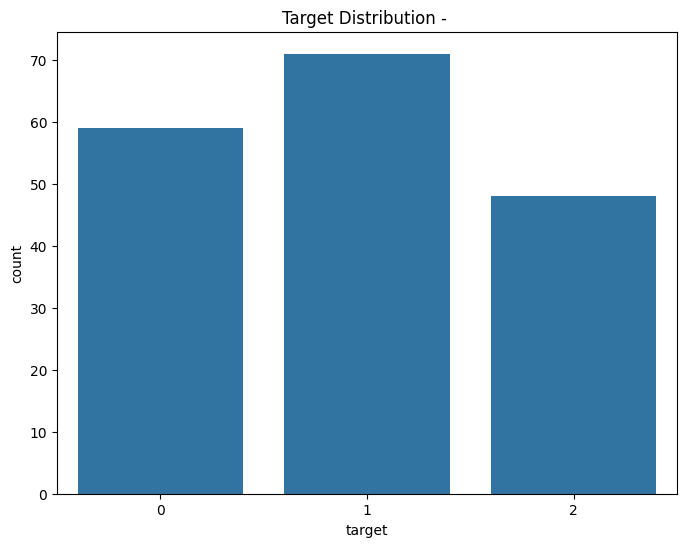

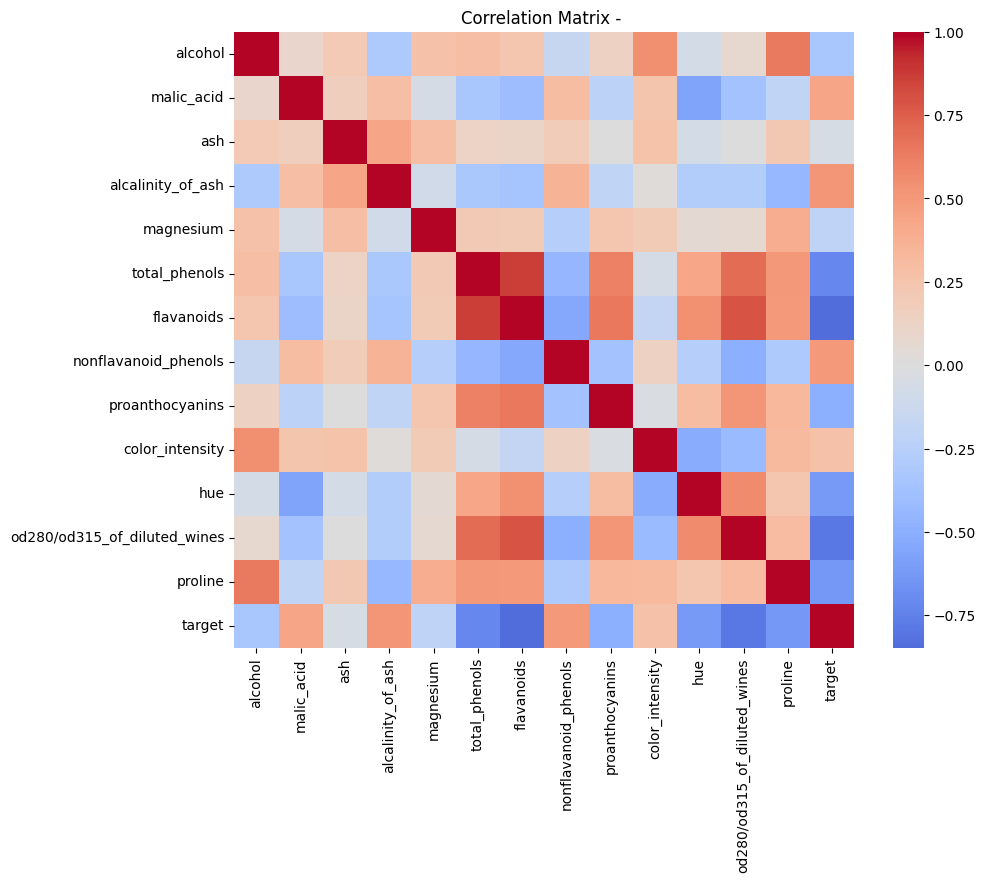

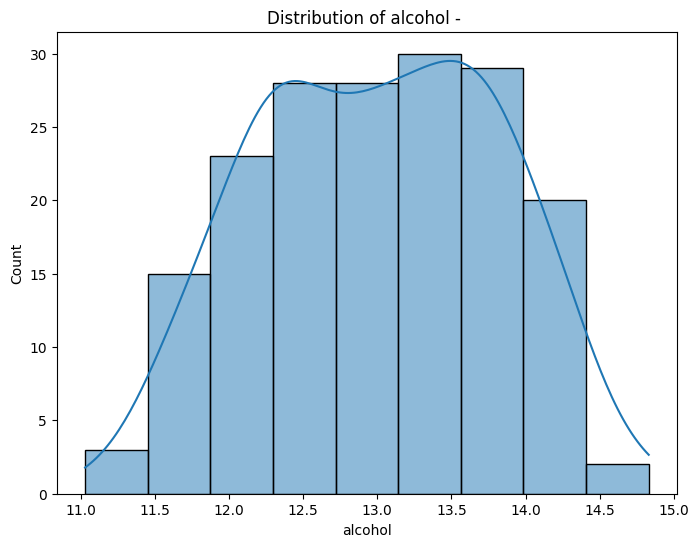

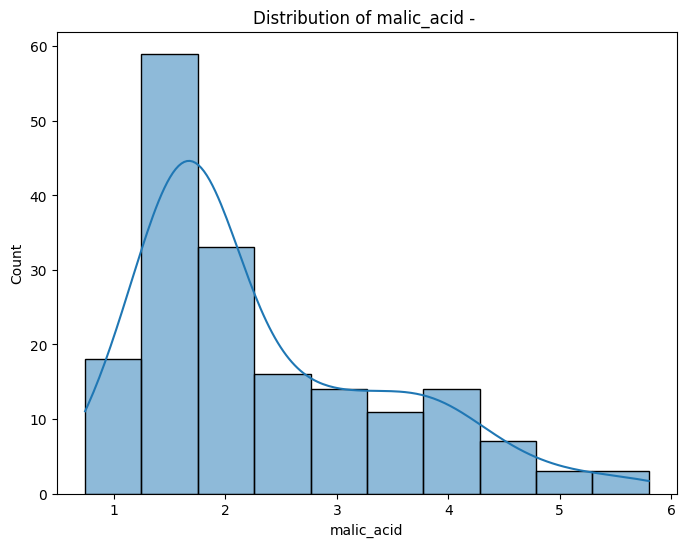

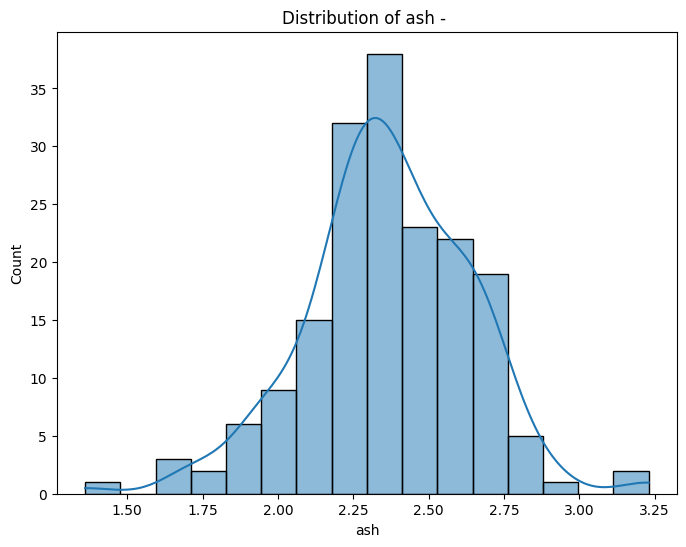

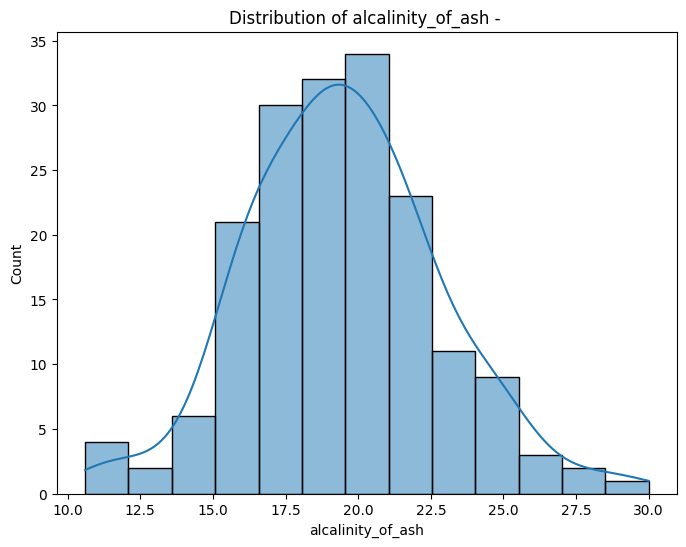

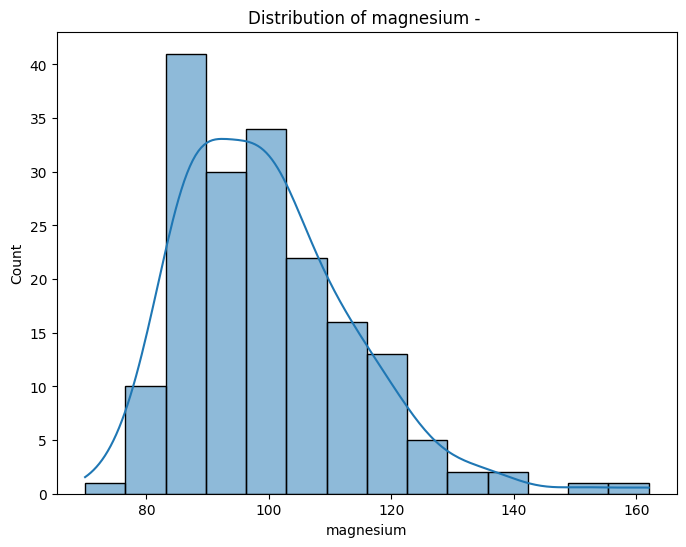





Evaluating models with all features...

📊 Model Evaluation for  (All Features)


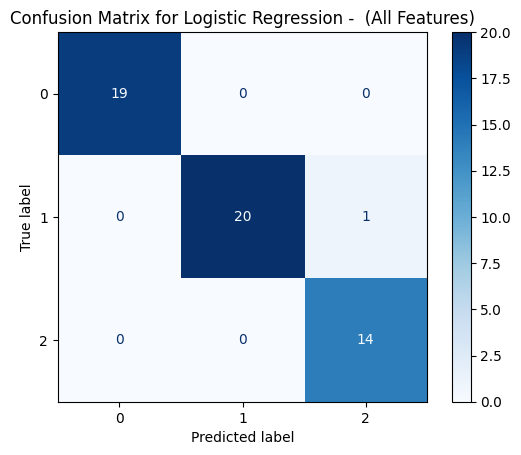

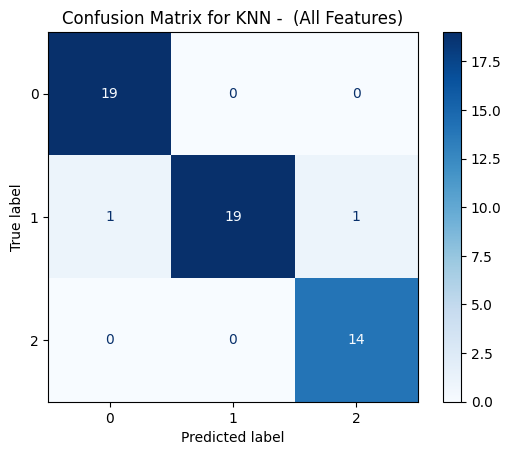

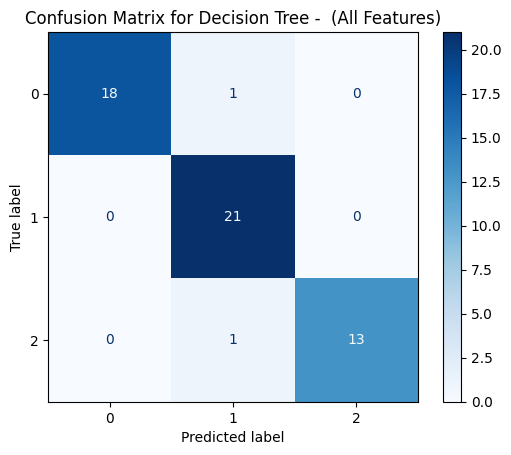

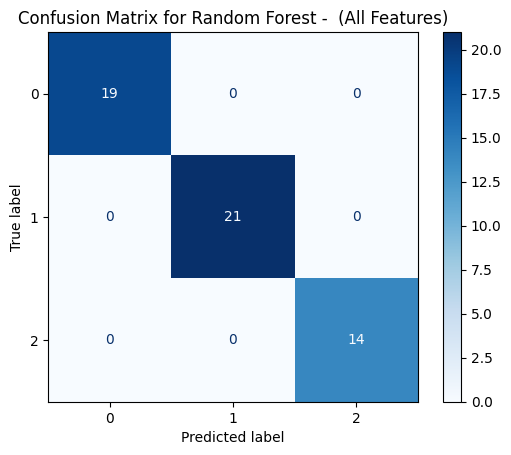

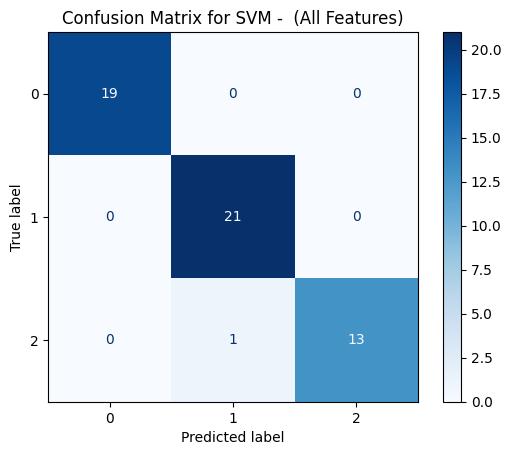

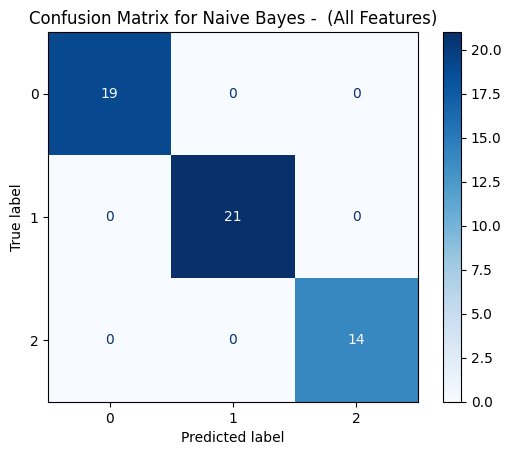





Model Performance Summary:
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.981481   0.982716  0.981481  0.981575
1                  KNN  0.962963   0.965123  0.962963  0.962594
2        Decision Tree  0.962963   0.966184  0.962963  0.963212
3        Random Forest  1.000000   1.000000  1.000000  1.000000
4                  SVM  0.981481   0.982323  0.981481  0.981354
5          Naive Bayes  1.000000   1.000000  1.000000  1.000000

Running ACO Feature Selection...
Iteration 1 | Best Accuracy: 0.9630 | Selected Features: 11
Iteration 2 | Best Accuracy: 1.0000 | Selected Features: 8
Iteration 3 | Best Accuracy: 1.0000 | Selected Features: 8
Early stopping due to stagnation.

Selected Features:
['malic_acid', 'ash', 'alcalinity_of_ash', 'nonflavanoid_phenols', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Best Accuracy with Selected Features: 1.0000

Evaluating models with selected features...

📊 Model Evaluation for  (ACO

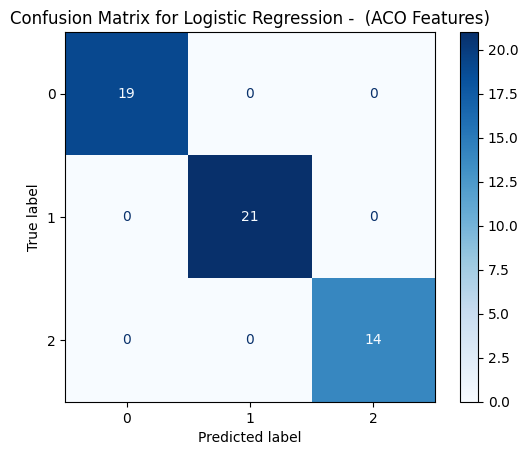

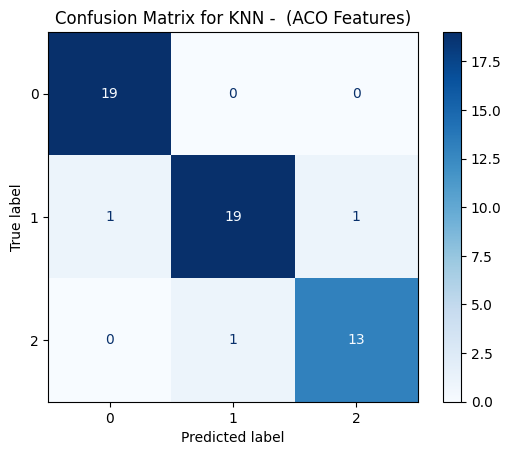

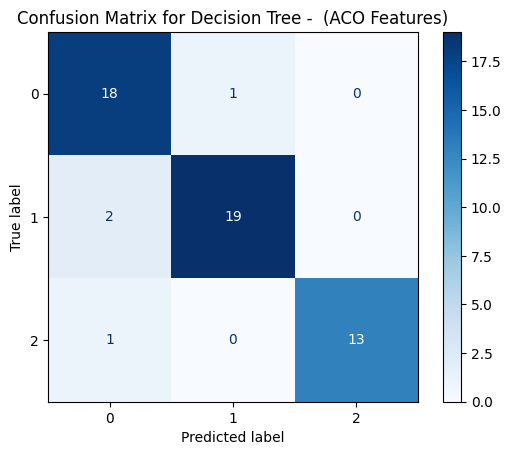

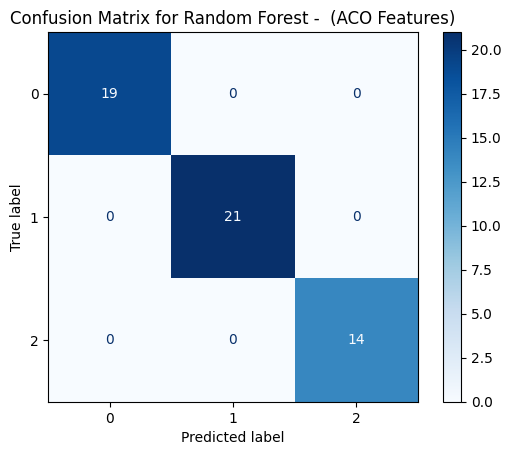

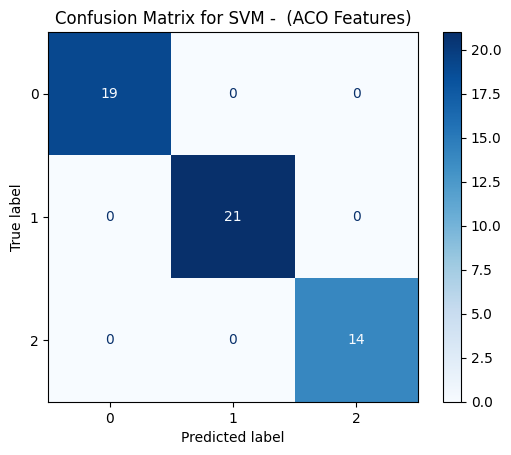

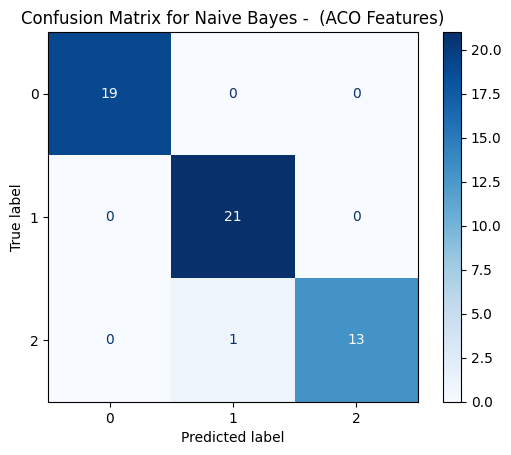





Model Performance Summary:
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  1.000000   1.000000  1.000000  1.000000
1                  KNN  0.944444   0.944444  0.944444  0.944004
2        Decision Tree  0.925926   0.930291  0.925926  0.926757
3        Random Forest  1.000000   1.000000  1.000000  1.000000
4                  SVM  1.000000   1.000000  1.000000  1.000000
5          Naive Bayes  0.981481   0.982323  0.981481  0.981354


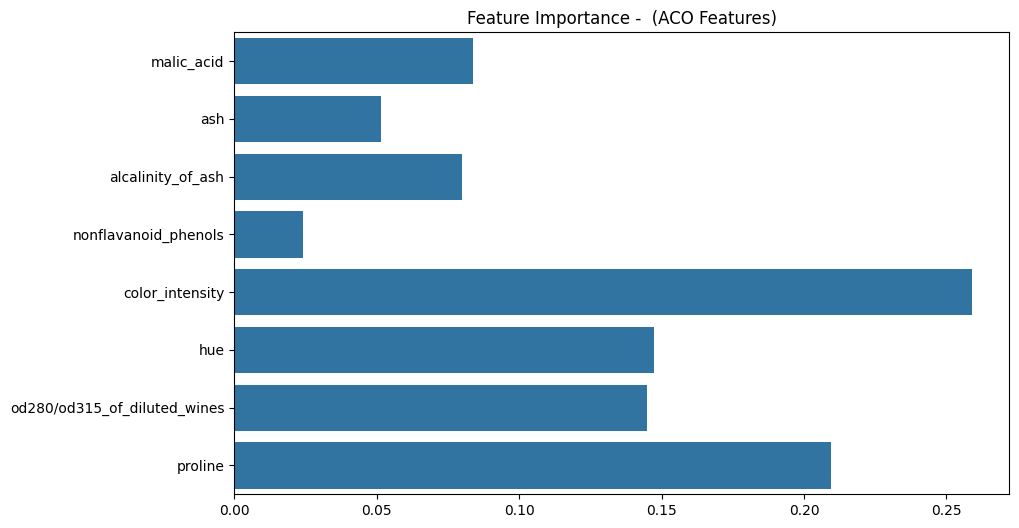





Accuracy Changes (ACO - All Features):
                 Model  All Features Accuracy  ACO Features Accuracy  \
0  Logistic Regression               0.981481               1.000000   
1                  KNN               0.962963               0.944444   
2        Decision Tree               0.962963               0.925926   
3        Random Forest               1.000000               1.000000   
4                  SVM               0.981481               1.000000   
5          Naive Bayes               1.000000               0.981481   

     Change  Change (%)  
0  0.018519    1.851852  
1 -0.018519   -1.851852  
2 -0.037037   -3.703704  
3  0.000000    0.000000  
4  0.018519    1.851852  
5 -0.018519   -1.851852  


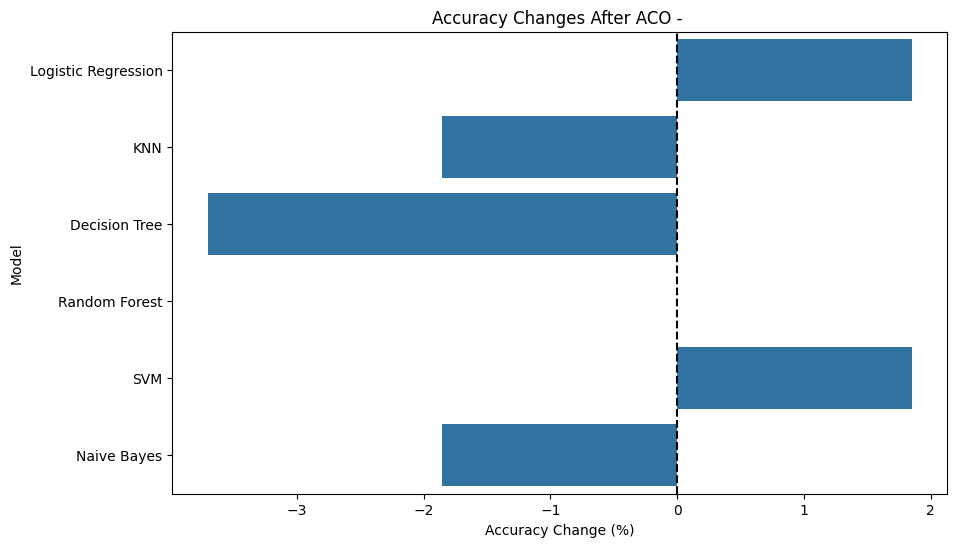


 Exploratory Data Analysis for 

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non

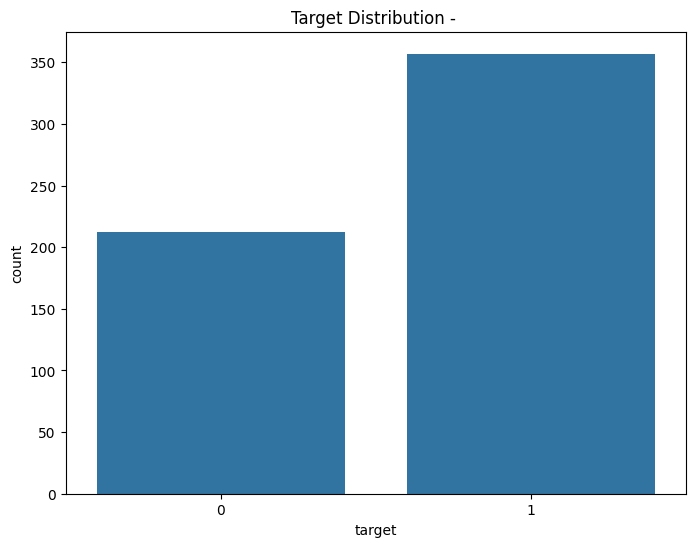

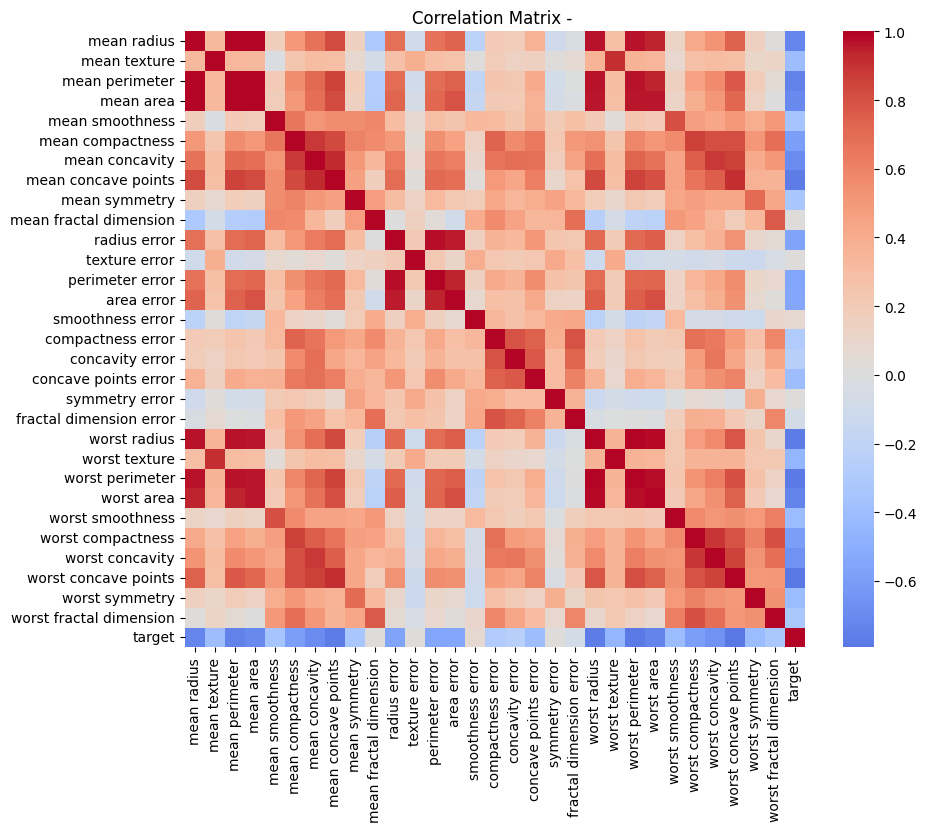

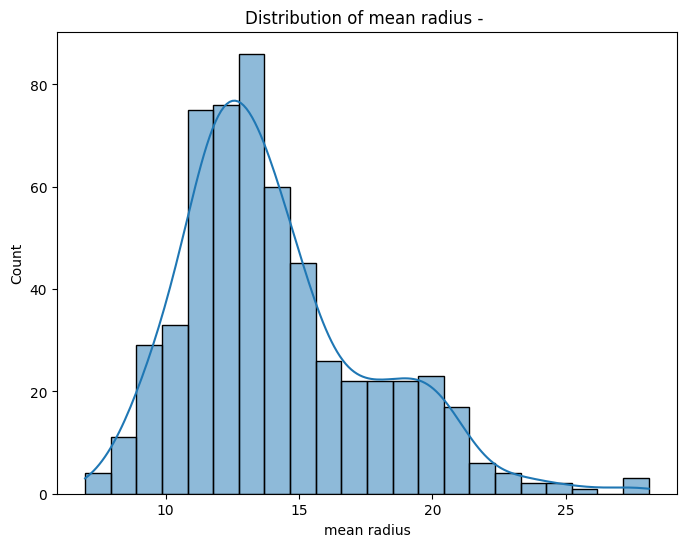

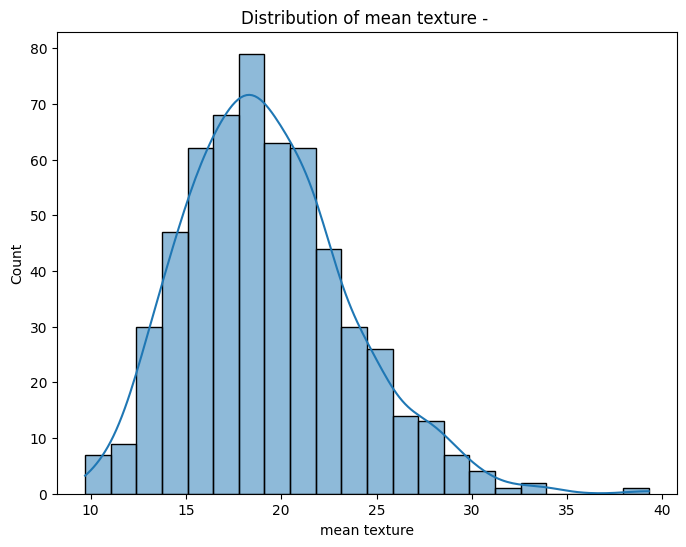

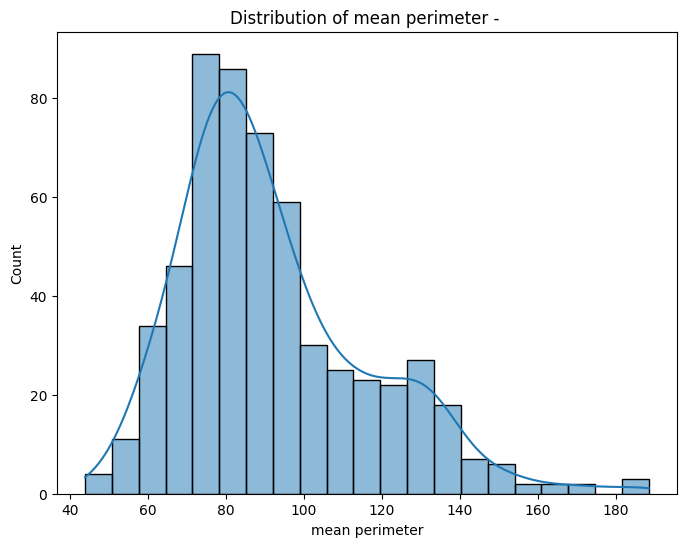

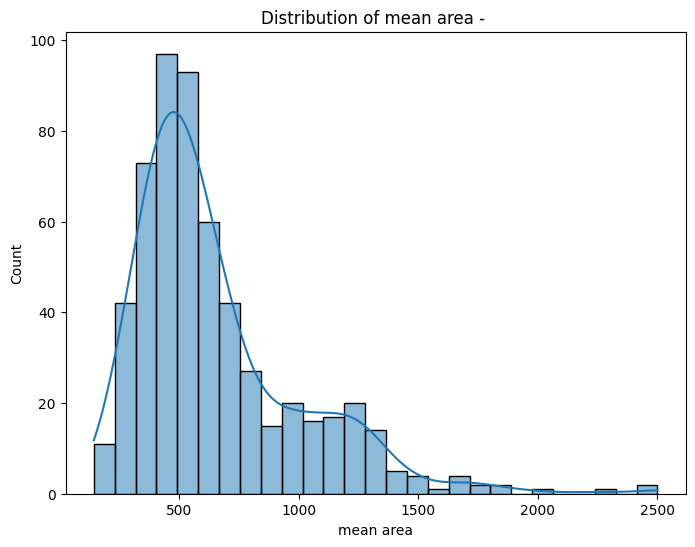

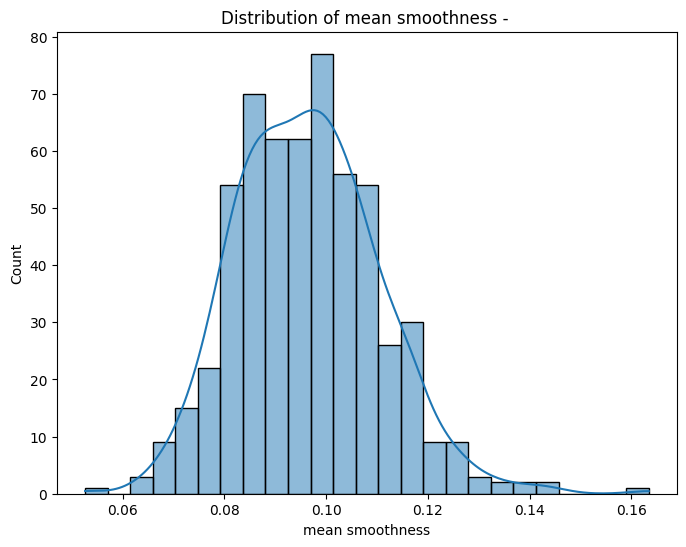





Evaluating models with all features...

📊 Model Evaluation for  (All Features)


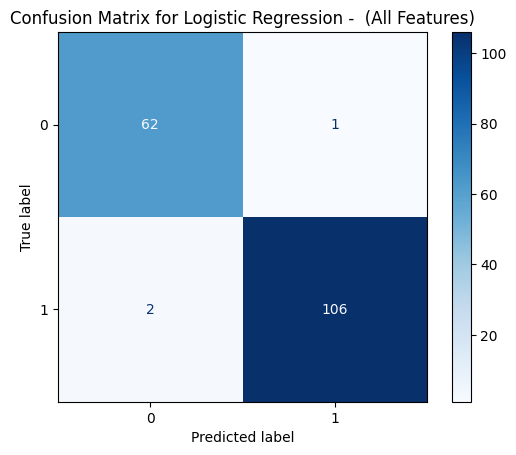

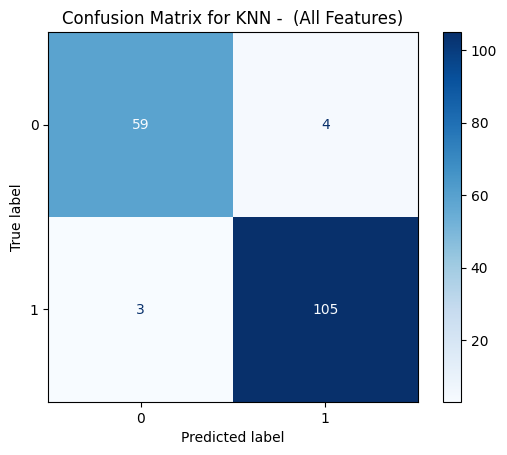

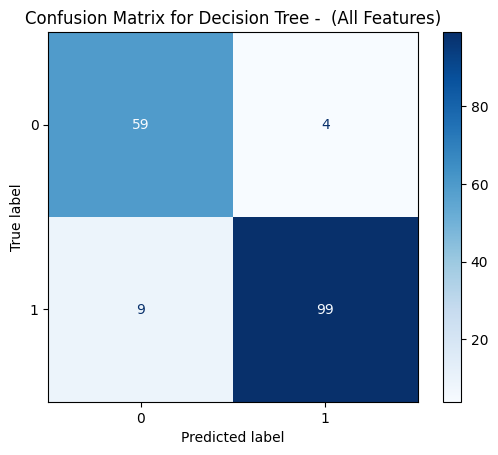

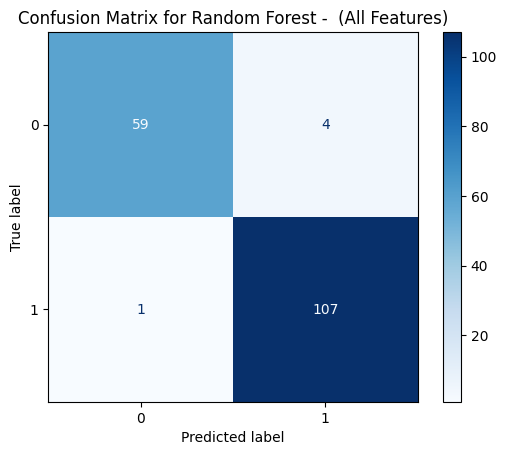

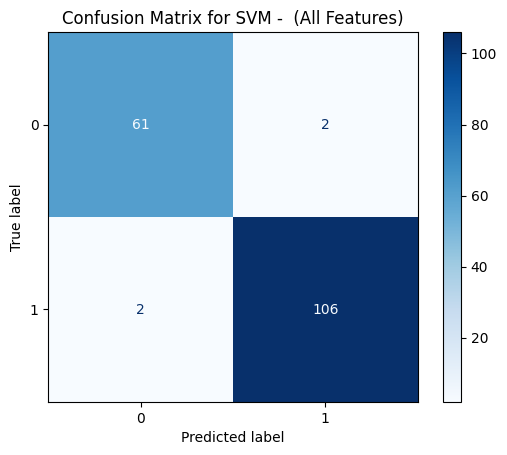

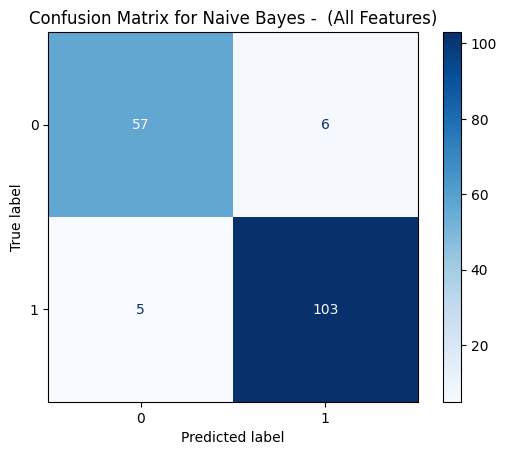





Model Performance Summary:
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.982456   0.982584  0.982456  0.982484
1                  KNN  0.959064   0.958996  0.959064  0.958995
2        Decision Tree  0.923977   0.926711  0.923977  0.924527
3        Random Forest  0.970760   0.971100  0.970760  0.970604
4                  SVM  0.976608   0.976608  0.976608  0.976608
5          Naive Bayes  0.935673   0.935523  0.935673  0.935563

Running ACO Feature Selection...
Iteration 1 | Best Accuracy: 0.9825 | Selected Features: 12
Iteration 2 | Best Accuracy: 0.9883 | Selected Features: 15
Iteration 3 | Best Accuracy: 0.9883 | Selected Features: 15
Early stopping due to stagnation.

Selected Features:
[np.str_('mean perimeter'), np.str_('mean compactness'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('texture error'), np.str_('area error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('concave points erro

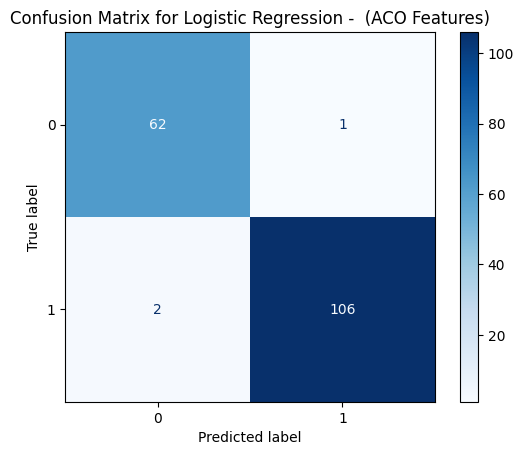

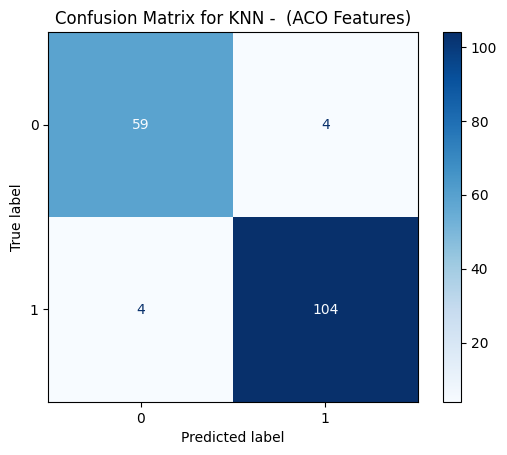

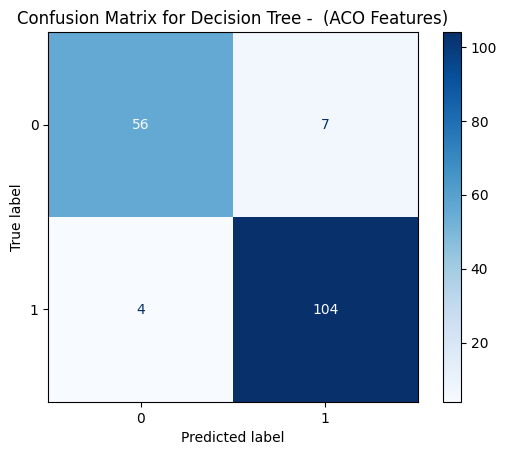

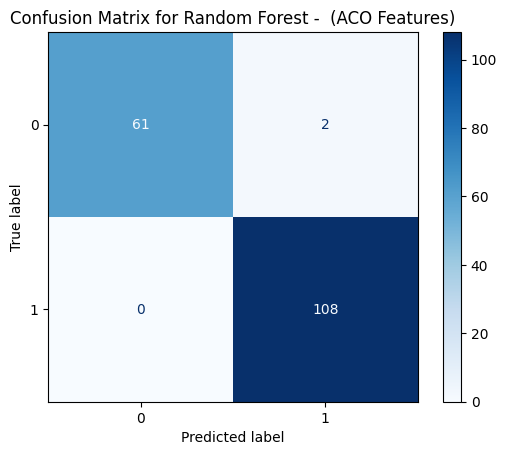

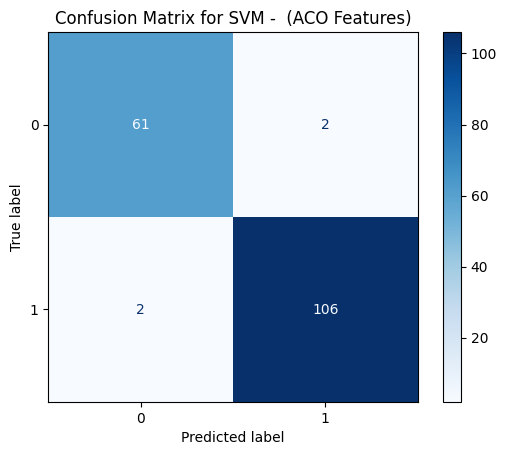

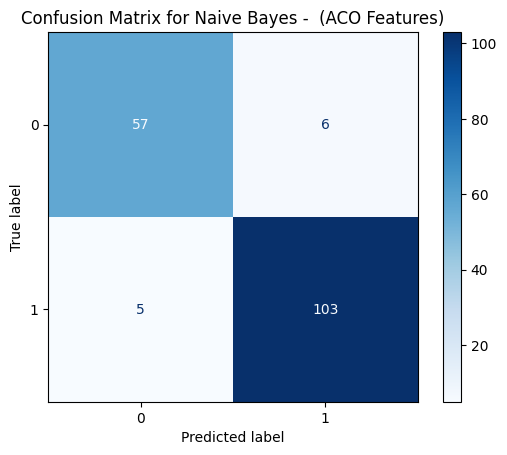





Model Performance Summary:
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.982456   0.982584  0.982456  0.982484
1                  KNN  0.953216   0.953216  0.953216  0.953216
2        Decision Tree  0.935673   0.935609  0.935673  0.935329
3        Random Forest  0.988304   0.988517  0.988304  0.988263
4                  SVM  0.976608   0.976608  0.976608  0.976608
5          Naive Bayes  0.935673   0.935523  0.935673  0.935563


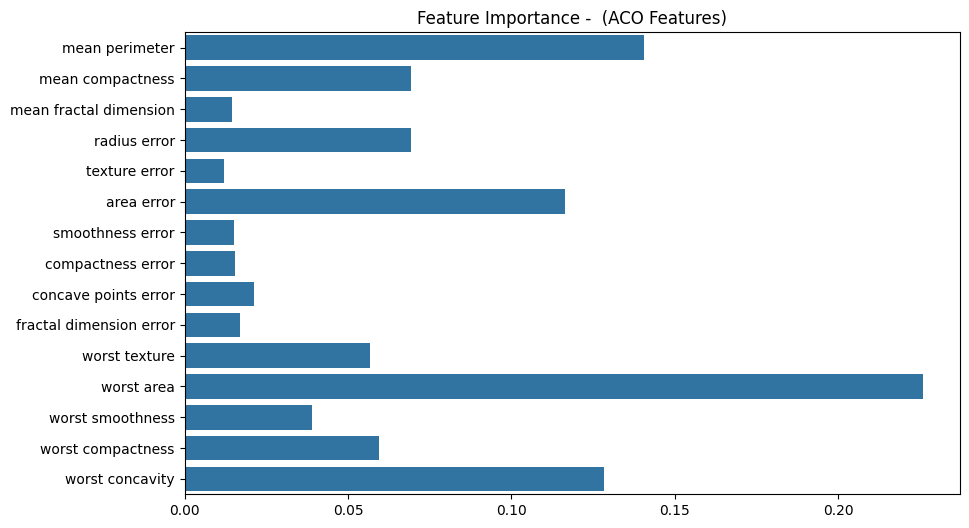





Accuracy Changes (ACO - All Features):
                 Model  All Features Accuracy  ACO Features Accuracy  \
0  Logistic Regression               0.982456               0.982456   
1                  KNN               0.959064               0.953216   
2        Decision Tree               0.923977               0.935673   
3        Random Forest               0.970760               0.988304   
4                  SVM               0.976608               0.976608   
5          Naive Bayes               0.935673               0.935673   

     Change  Change (%)  
0  0.000000    0.000000  
1 -0.005848   -0.584795  
2  0.011696    1.169591  
3  0.017544    1.754386  
4  0.000000    0.000000  
5  0.000000    0.000000  


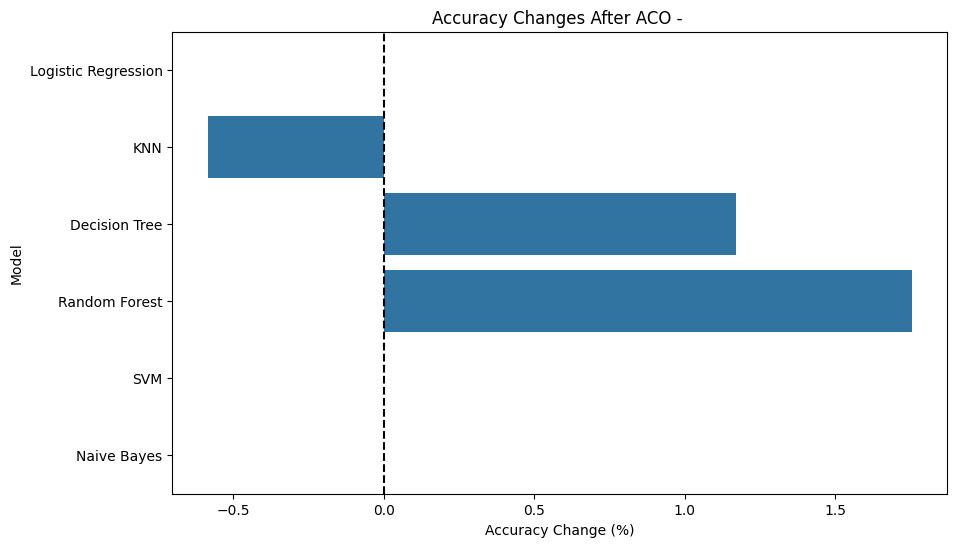

(                 Model  Accuracy  Precision    Recall  F1-Score
 0  Logistic Regression  0.982456   0.982584  0.982456  0.982484
 1                  KNN  0.959064   0.958996  0.959064  0.958995
 2        Decision Tree  0.923977   0.926711  0.923977  0.924527
 3        Random Forest  0.970760   0.971100  0.970760  0.970604
 4                  SVM  0.976608   0.976608  0.976608  0.976608
 5          Naive Bayes  0.935673   0.935523  0.935673  0.935563,
                  Model  Accuracy  Precision    Recall  F1-Score
 0  Logistic Regression  0.982456   0.982584  0.982456  0.982484
 1                  KNN  0.953216   0.953216  0.953216  0.953216
 2        Decision Tree  0.935673   0.935609  0.935673  0.935329
 3        Random Forest  0.988304   0.988517  0.988304  0.988263
 4                  SVM  0.976608   0.976608  0.976608  0.976608
 5          Naive Bayes  0.935673   0.935523  0.935673  0.935563,
                  Model  All Features Accuracy  ACO Features Accuracy  \
 0  Logistic Re

In [ ]:
run_feature_selection_pipeline(load_wine())  # Uses default 'target' column
run_feature_selection_pipeline(load_breast_cancer())

Processing Digits Dataset...

📊 Exploratory Data Analysis for 

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pixel_0_0  1797 non-null   float64
 1   pixel_0_1  1797 non-null   float64
 2   pixel_0_2  1797 non-null   float64
 3   pixel_0_3  1797 non-null   float64
 4   pixel_0_4  1797 non-null   float64
 5   pixel_0_5  1797 non-null   float64
 6   pixel_0_6  1797 non-null   float64
 7   pixel_0_7  1797 non-null   float64
 8   pixel_1_0  1797 non-null   float64
 9   pixel_1_1  1797 non-null   float64
 10  pixel_1_2  1797 non-null   float64
 11  pixel_1_3  1797 non-null   float64
 12  pixel_1_4  1797 non-null   float64
 13  pixel_1_5  1797 non-null   float64
 14  pixel_1_6  1797 non-null   float64
 15  pixel_1_7  1797 non-null   float64
 16  pixel_2_0  1797 non-null   float64
 17  pixel_2_1  1797 non-null   float64
 18  pixel_2_2 

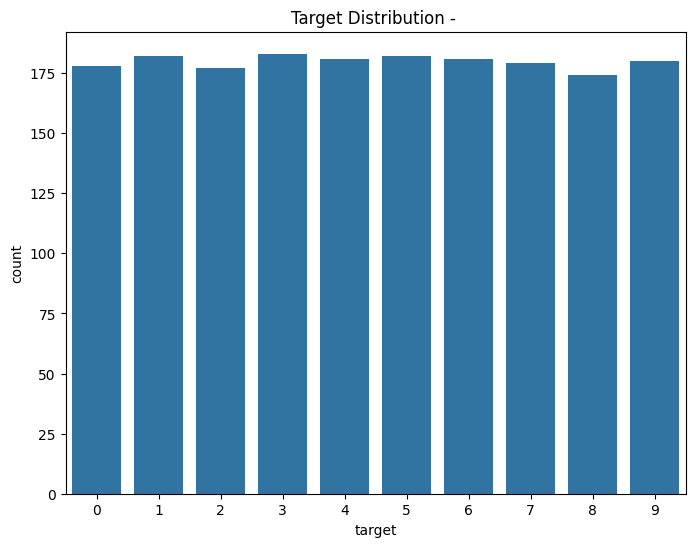

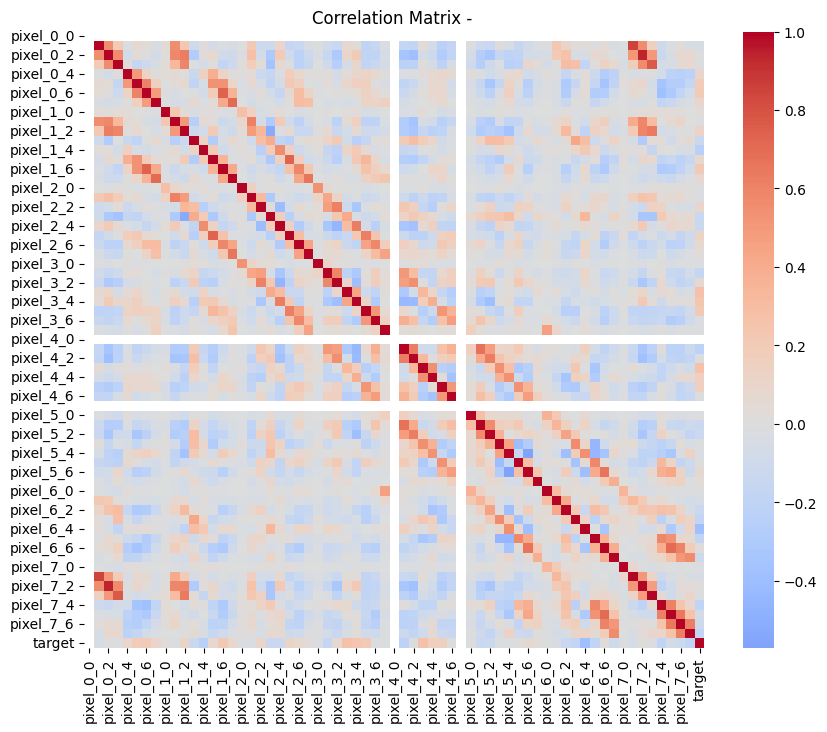

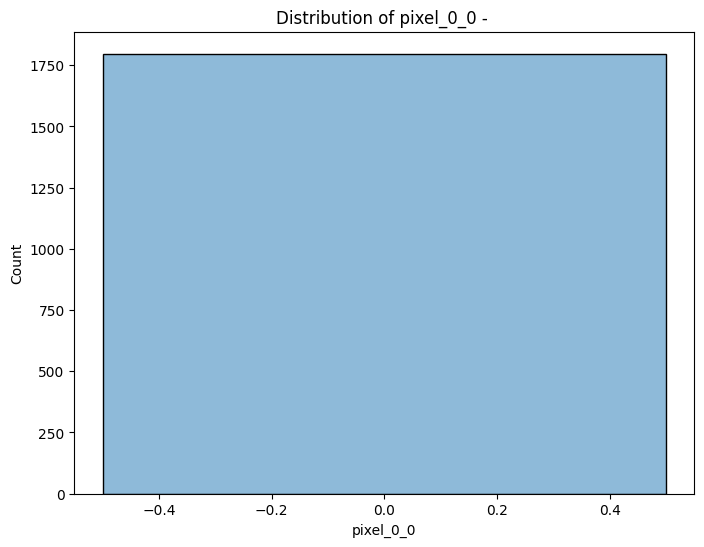

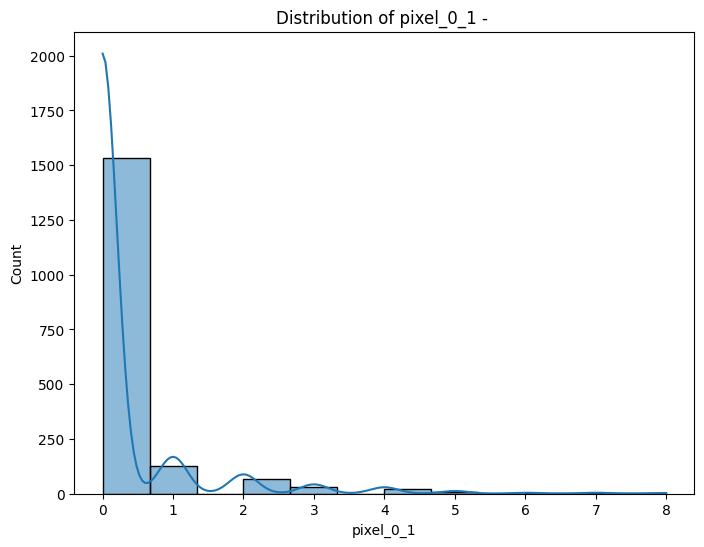

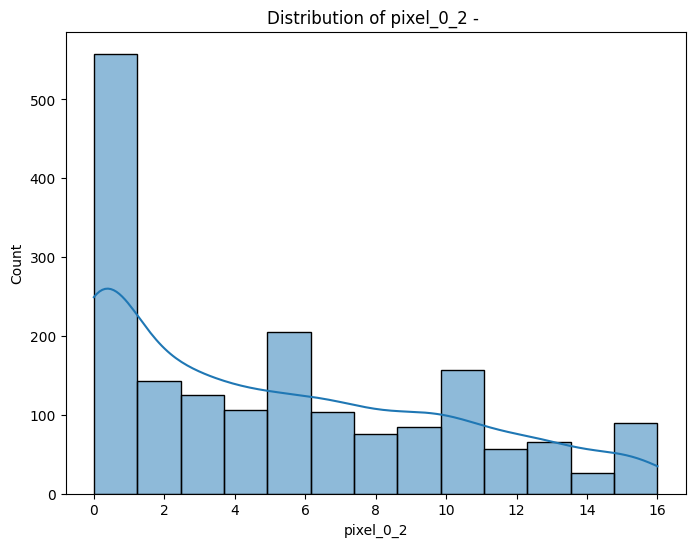

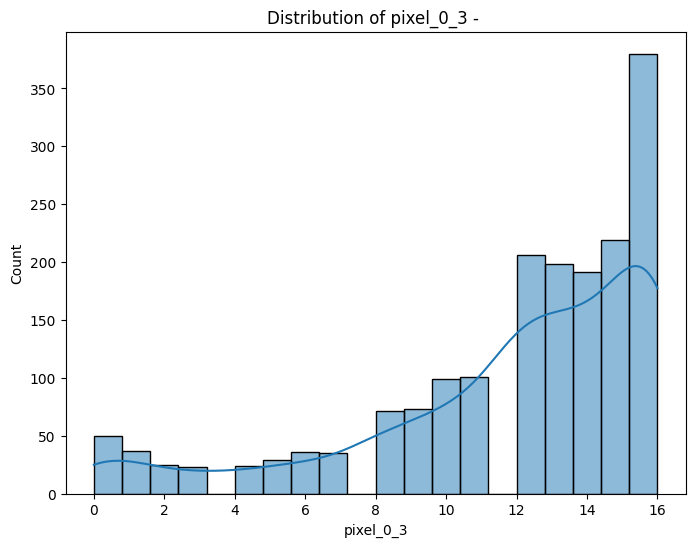

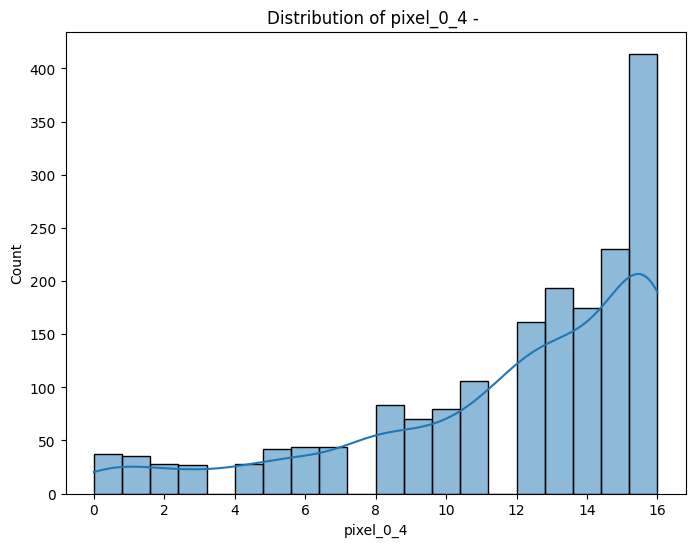





Evaluating models with all features...

📊 Model Evaluation for  (All Features)


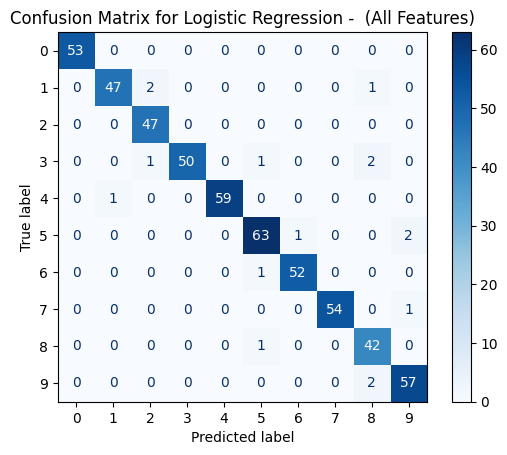

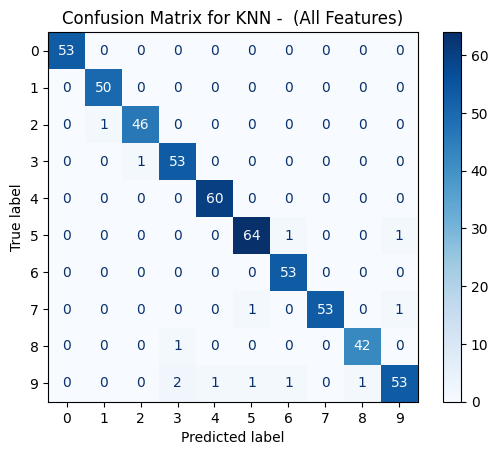

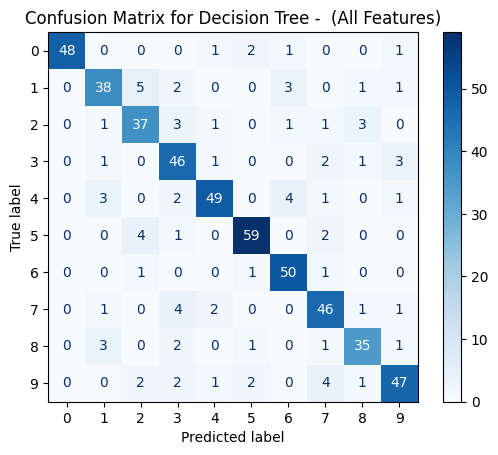

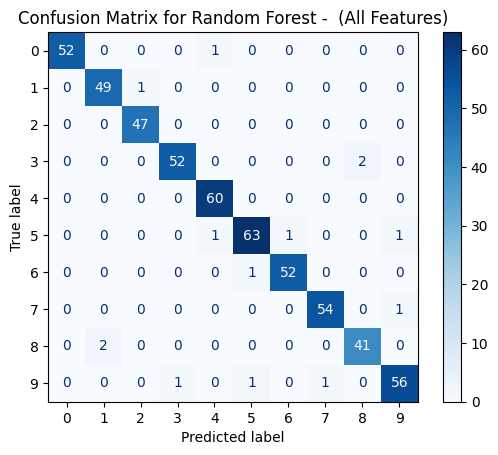

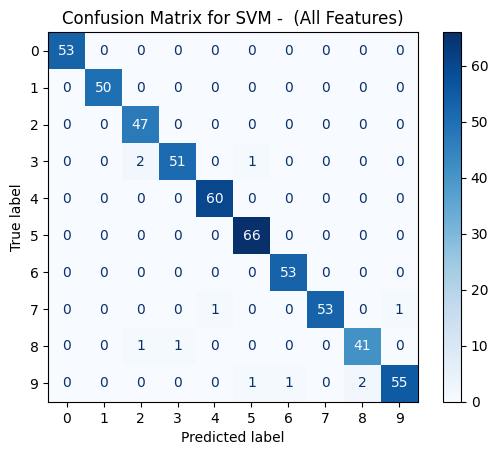

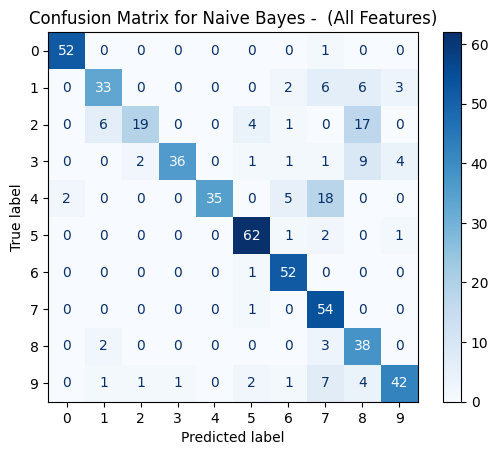





Model Performance Summary:
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.970370   0.971507  0.970370  0.970508
1                  KNN  0.975926   0.976056  0.975926  0.975750
2        Decision Tree  0.842593   0.846536  0.842593  0.843241
3        Random Forest  0.974074   0.974149  0.974074  0.974032
4                  SVM  0.979630   0.979966  0.979630  0.979535
5          Naive Bayes  0.783333   0.831033  0.783333  0.780121

Running ACO Feature Selection...
Iteration 1 | Best Accuracy: 0.9611 | Selected Features: 31
Iteration 2 | Best Accuracy: 0.9796 | Selected Features: 39
Iteration 3 | Best Accuracy: 0.9796 | Selected Features: 39
Early stopping due to stagnation.

Selected Features:
['pixel_0_1', 'pixel_0_3', 'pixel_0_5', 'pixel_0_6', 'pixel_1_0', 'pixel_1_1', 'pixel_1_2', 'pixel_1_3', 'pixel_1_4', 'pixel_1_5', 'pixel_2_0', 'pixel_2_2', 'pixel_2_3', 'pixel_2_4', 'pixel_2_5', 'pixel_3_2', 'pixel_3_3', 'pixel_3_4', 'pixel_3_5', 'pixe

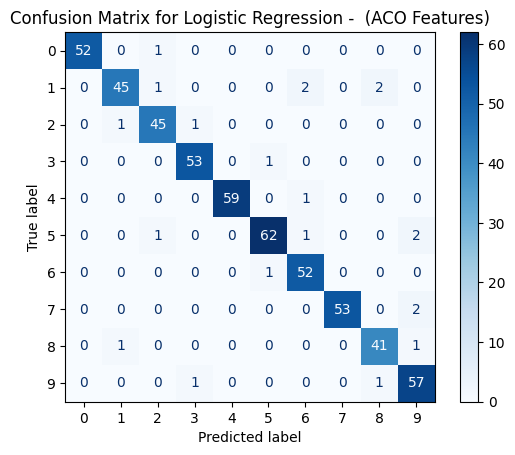

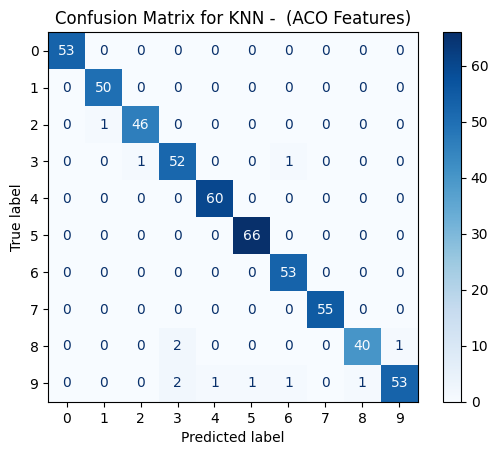

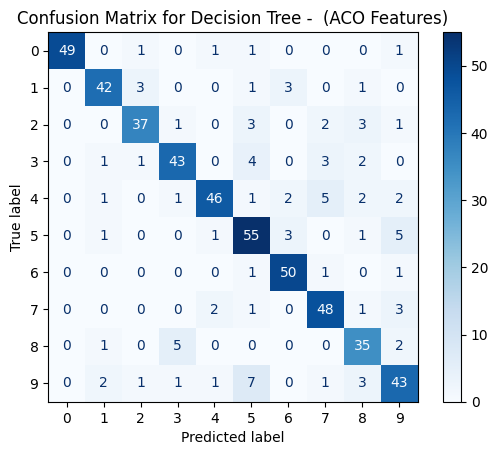

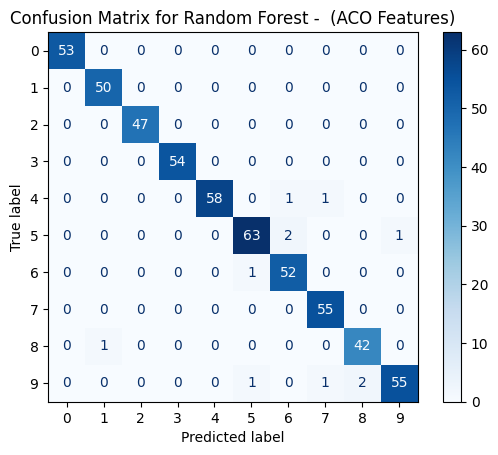

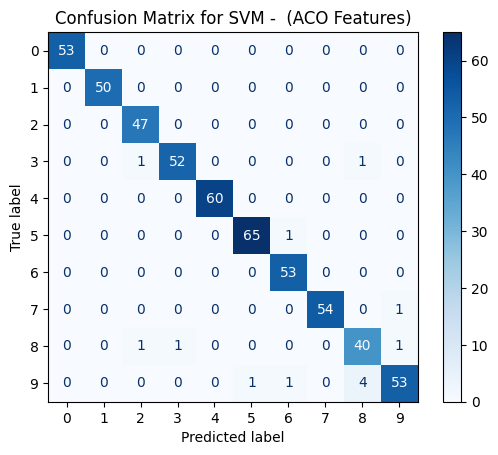

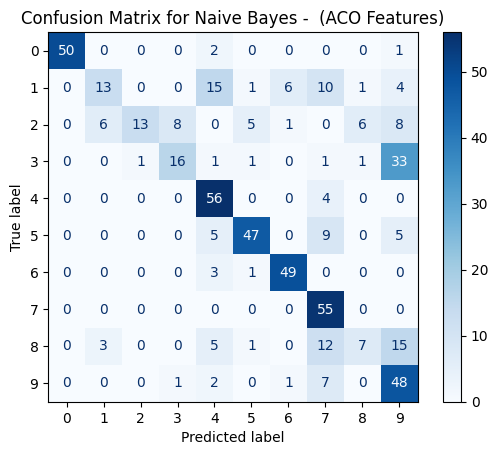





Model Performance Summary:
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.961111   0.961913  0.961111  0.961190
1                  KNN  0.977778   0.978010  0.977778  0.977562
2        Decision Tree  0.829630   0.834589  0.829630  0.830266
3        Random Forest  0.979630   0.979926  0.979630  0.979585
4                  SVM  0.975926   0.976319  0.975926  0.975873
5          Naive Bayes  0.655556   0.694873  0.655556  0.624539


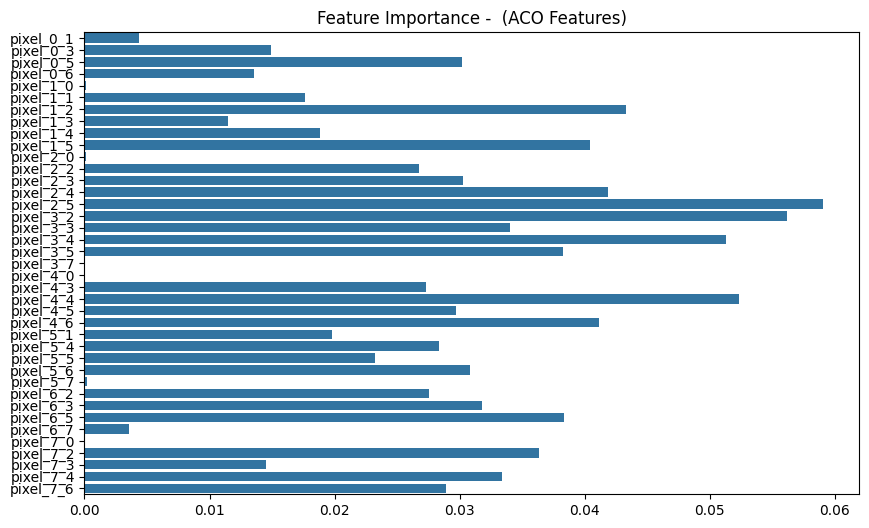

In [ ]:
from sklearn.datasets import load_digits
print("Processing Digits Dataset...")
run_feature_selection_pipeline(load_digits())


📊 Exploratory Data Analysis for 

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0.0200  207 non-null    float64
 1   0.0371  207 non-null    float64
 2   0.0428  207 non-null    float64
 3   0.0207  207 non-null    float64
 4   0.0954  207 non-null    float64
 5   0.0986  207 non-null    float64
 6   0.1539  207 non-null    float64
 7   0.1601  207 non-null    float64
 8   0.3109  207 non-null    float64
 9   0.2111  207 non-null    float64
 10  0.1609  207 non-null    float64
 11  0.1582  207 non-null    float64
 12  0.2238  207 non-null    float64
 13  0.0645  207 non-null    float64
 14  0.0660  207 non-null    float64
 15  0.2273  207 non-null    float64
 16  0.3100  207 non-null    float64
 17  0.2999  207 non-null    float64
 18  0.5078  207 non-null    float64
 19  0.4797  207 non-null    float64
 20  0.5783  207 non-null    flo

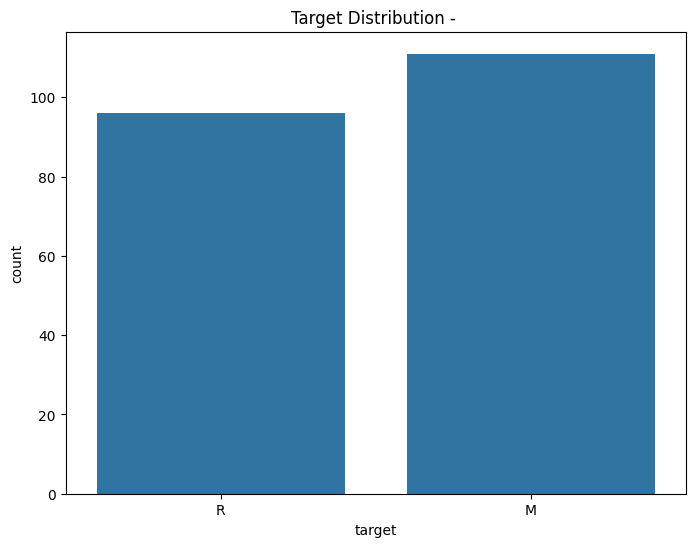

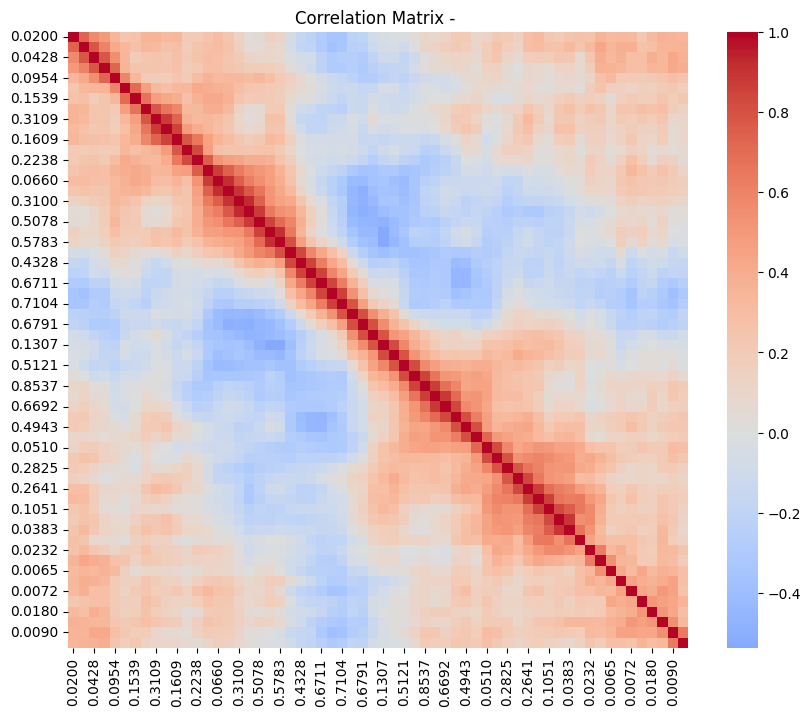

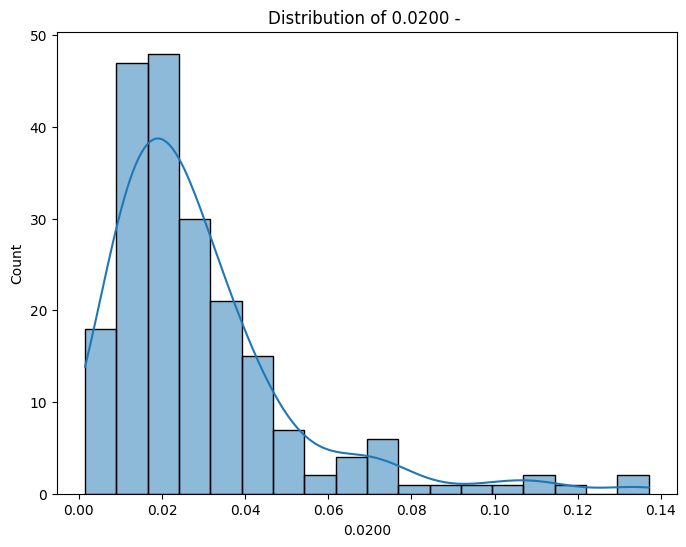

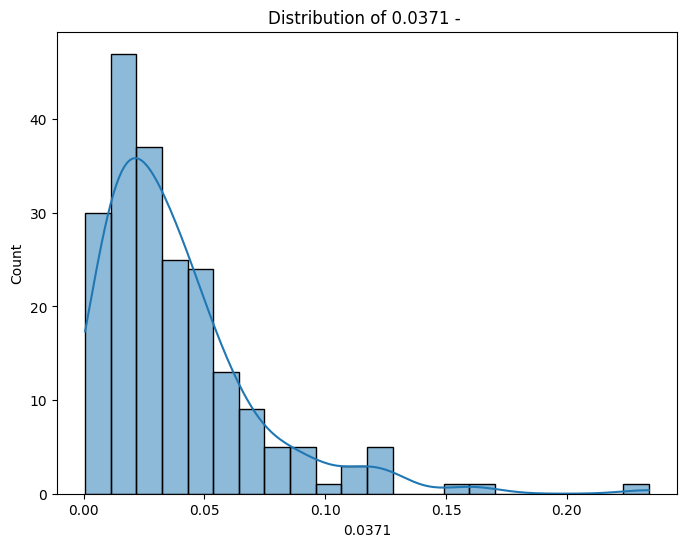

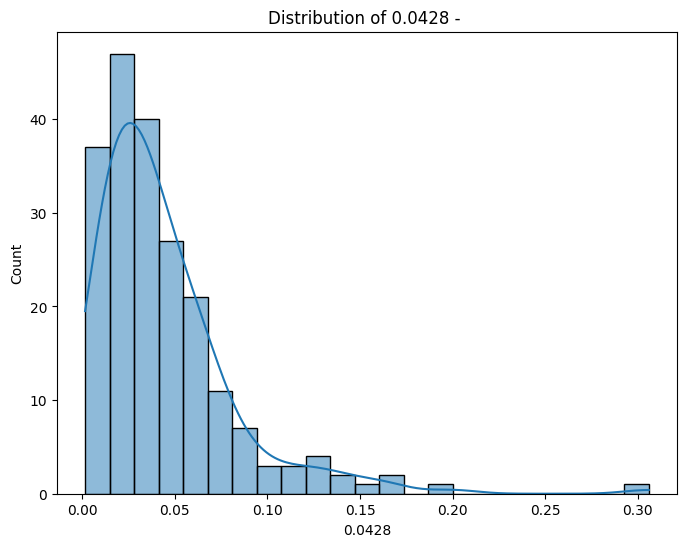

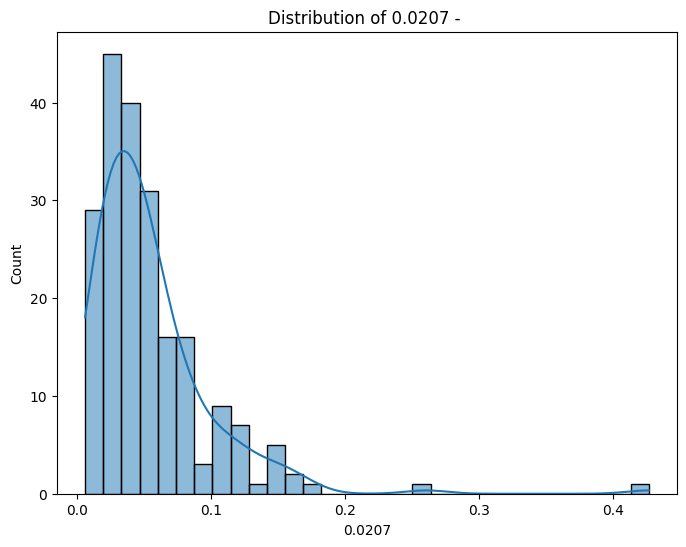

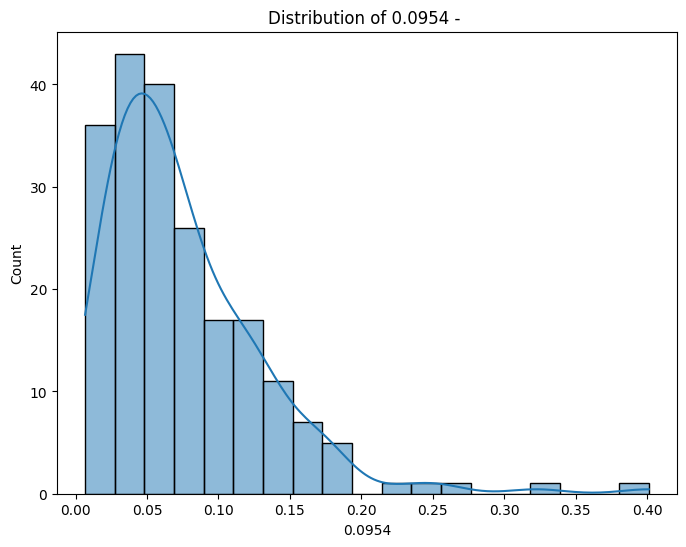





Evaluating models with all features...

📊 Model Evaluation for  (All Features)


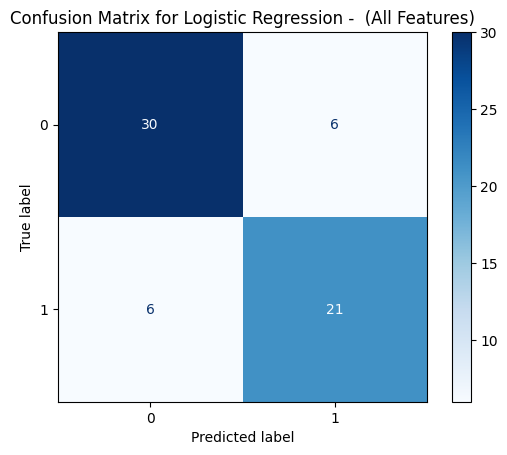

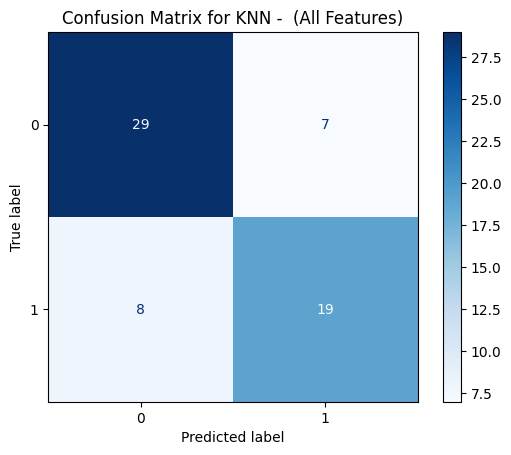

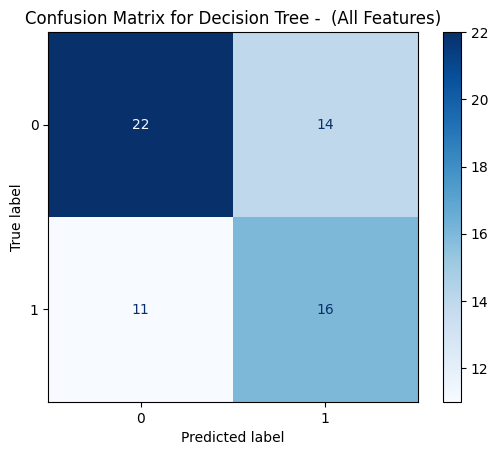

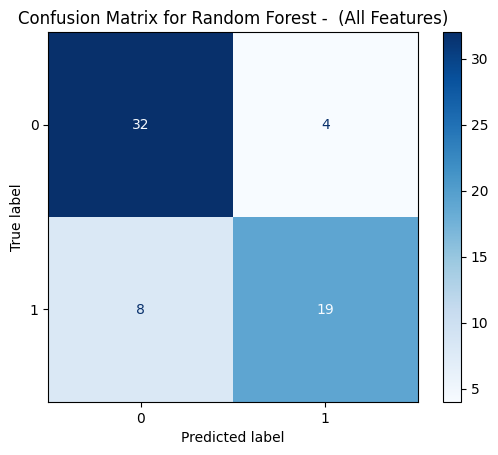

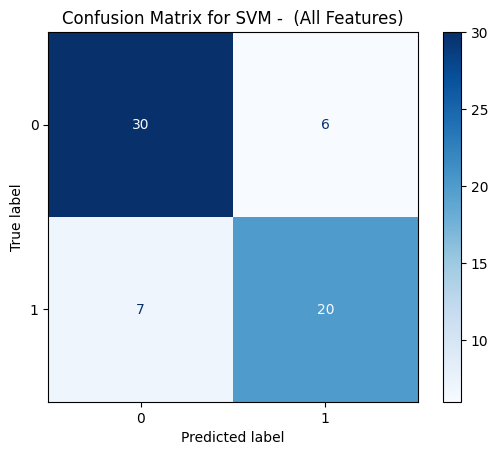

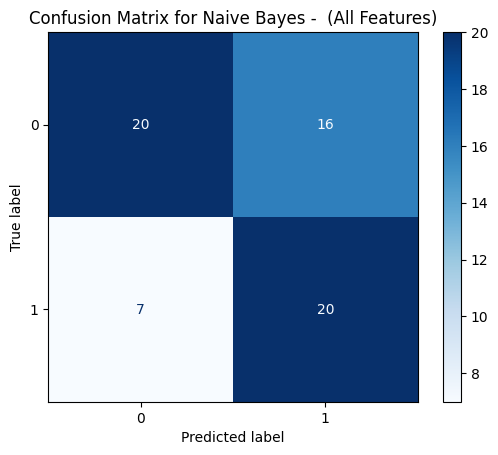





Model Performance Summary:
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.809524   0.809524  0.809524  0.809524
1                  KNN  0.761905   0.761063  0.761905  0.761289
2        Decision Tree  0.603175   0.609524  0.603175  0.604991
3        Random Forest  0.809524   0.811180  0.809524  0.806917
4                  SVM  0.793651   0.792991  0.793651  0.793117
5          Naive Bayes  0.634921   0.661376  0.634921  0.634921

Running ACO Feature Selection...
Iteration 1 | Best Accuracy: 0.8571 | Selected Features: 37
Iteration 2 | Best Accuracy: 0.8571 | Selected Features: 37
Early stopping due to stagnation.

Selected Features:
['0.0200', '0.0428', '0.0954', '0.0986', '0.1539', '0.1609', '0.1582', '0.2238', '0.0645', '0.2273', '0.3100', '0.2999', '0.4797', '0.4328', '0.6711', '0.6415', '0.8080', '0.3857', '0.1307', '0.7547', '0.8507', '0.6692', '0.6097', '0.4943', '0.2744', '0.0510', '0.2825', '0.1343', '0.0383', '0.0232', '0.0027', '0

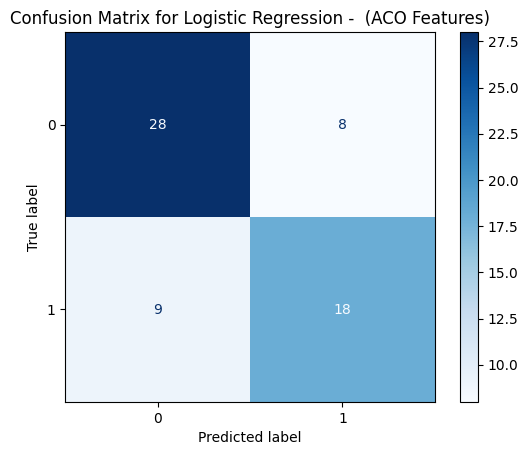

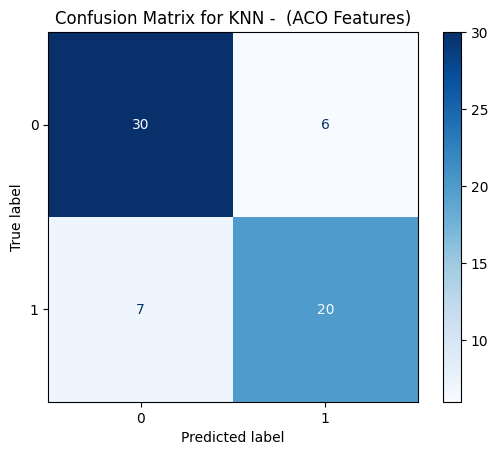

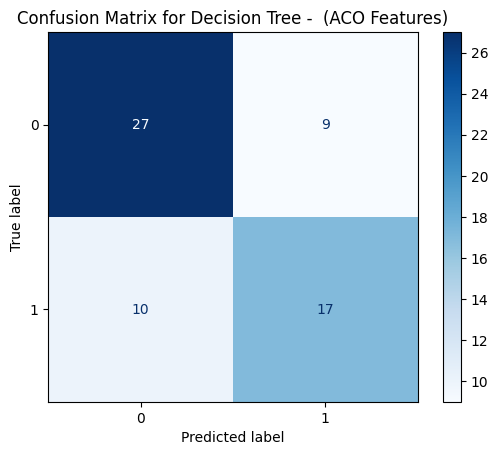

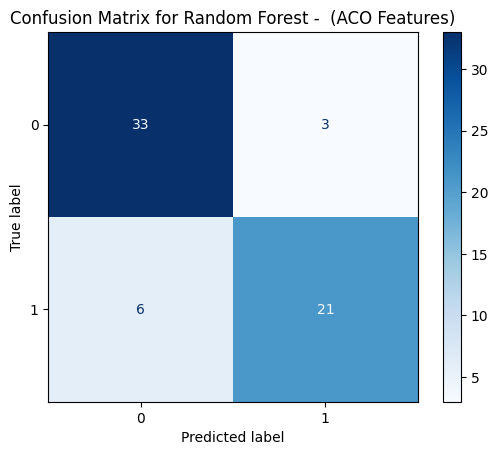

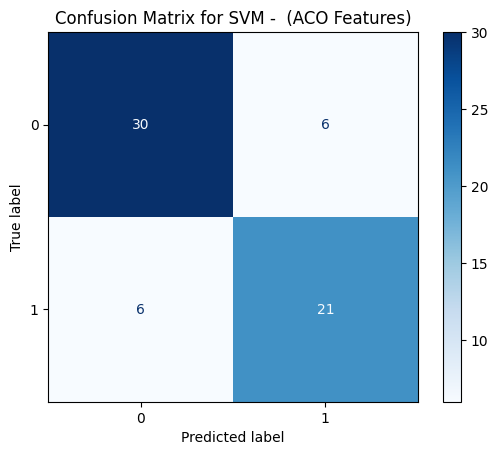

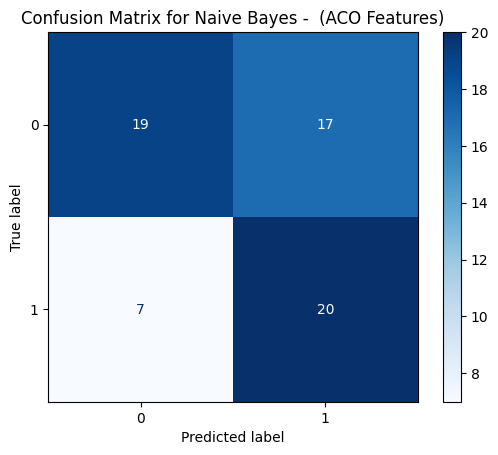





Model Performance Summary:
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.730159   0.729136  0.730159  0.729461
1                  KNN  0.793651   0.792991  0.793651  0.793117
2        Decision Tree  0.698413   0.697208  0.698413  0.697633
3        Random Forest  0.857143   0.858516  0.857143  0.855798
4                  SVM  0.809524   0.809524  0.809524  0.809524
5          Naive Bayes  0.619048   0.649243  0.619048  0.618088


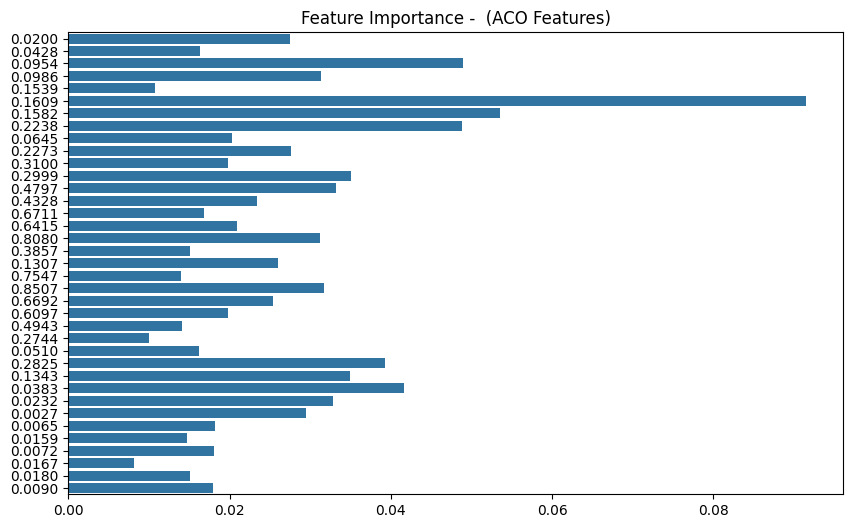

In [ ]:
sonar_data = load_csv_as_sklearn(
    csv_path="/content/sonar.csv"
)
run_feature_selection_pipeline(sonar_data)


📊 Exploratory Data Analysis for 

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   383 non-null    int64 
 1   Gender                383 non-null    int64 
 2   Smoking               383 non-null    int64 
 3   Hx Smoking            383 non-null    int64 
 4   Hx Radiothreapy       383 non-null    int64 
 5   Thyroid Function      383 non-null    int64 
 6   Physical Examination  383 non-null    int64 
 7   Adenopathy            383 non-null    int64 
 8   Pathology             383 non-null    int64 
 9   Focality              383 non-null    int64 
 10  Risk                  383 non-null    int64 
 11  T                     383 non-null    int64 
 12  N                     383 non-null    int64 
 13  M                     383 non-null    int64 
 14  Stage                 383 non-null    int

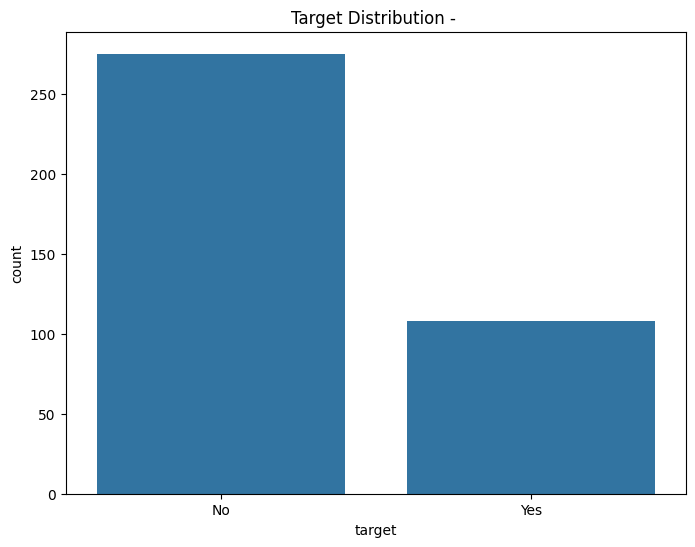

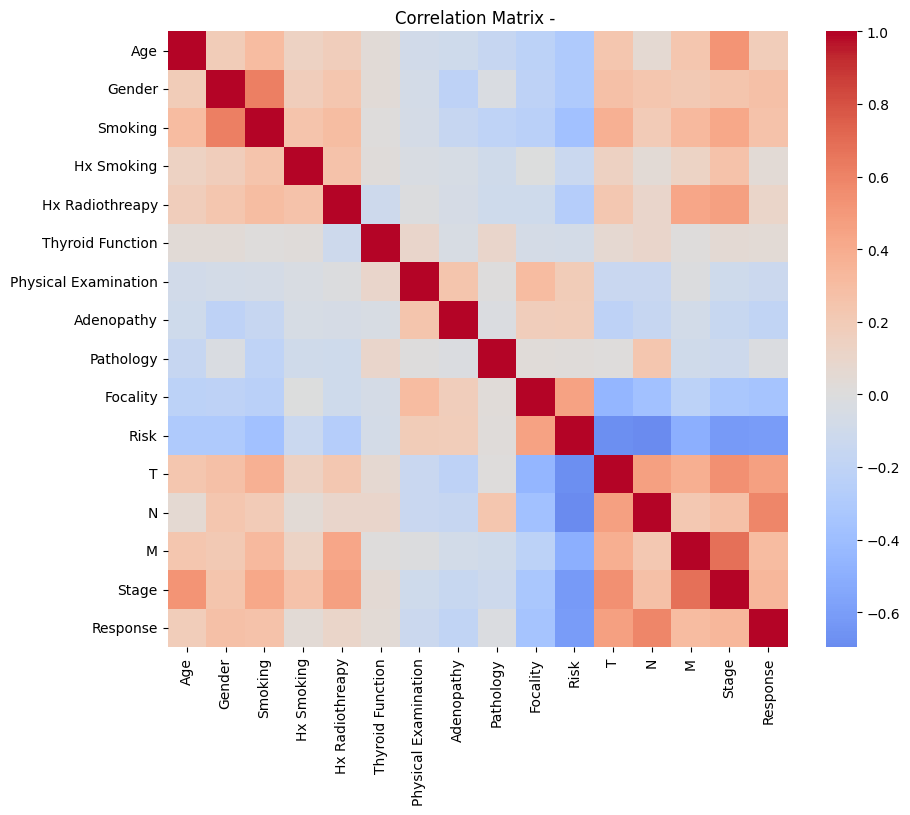

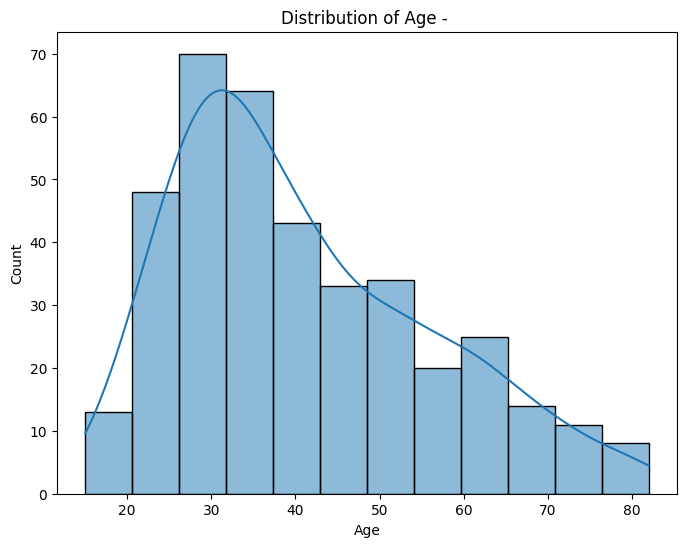

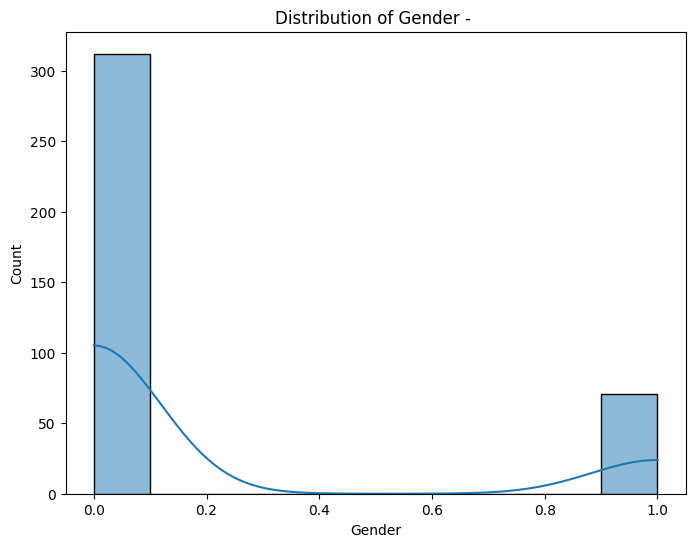

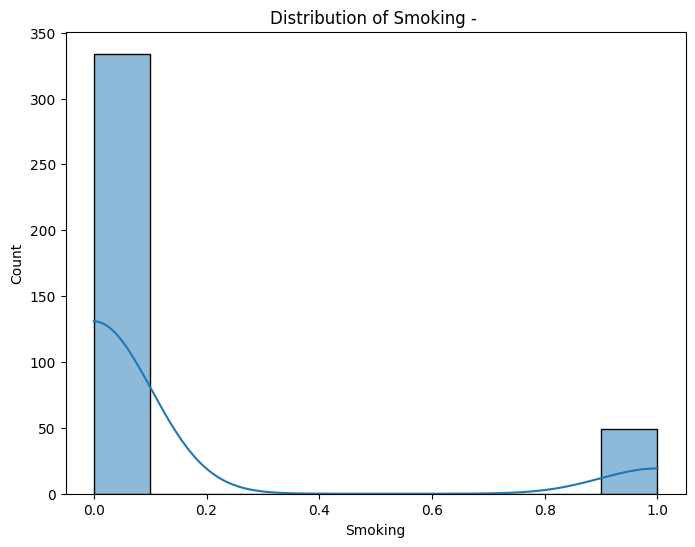

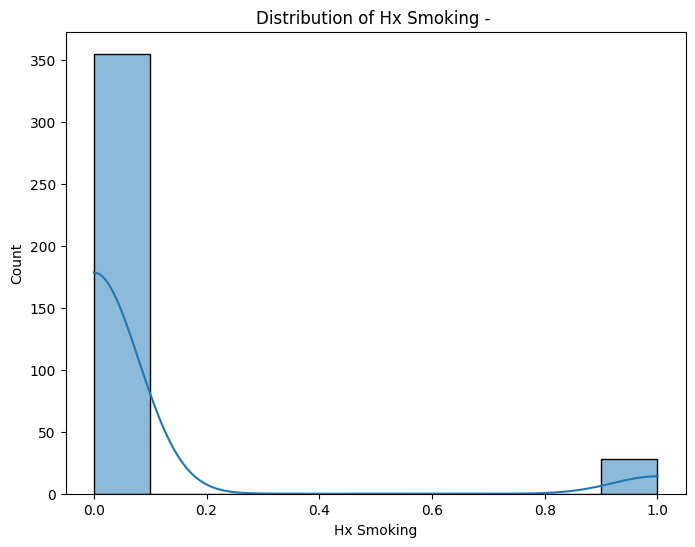

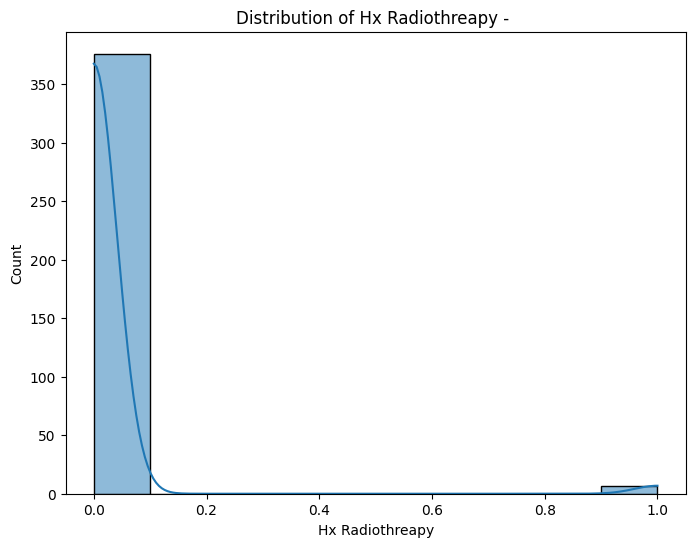





Evaluating models with all features...

📊 Model Evaluation for  (All Features)


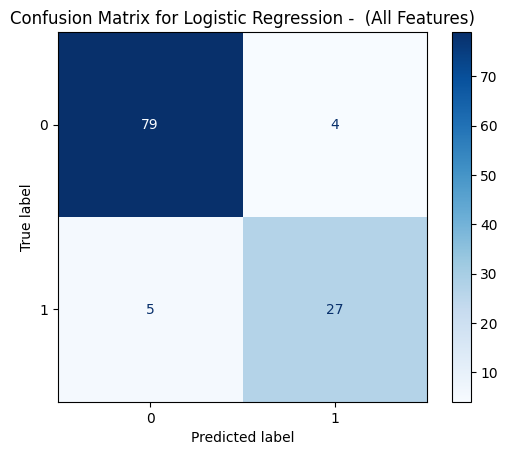

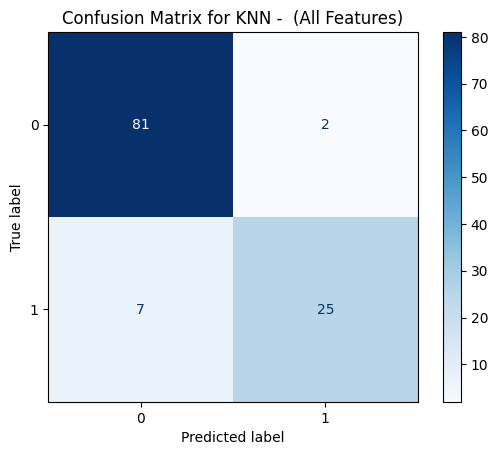

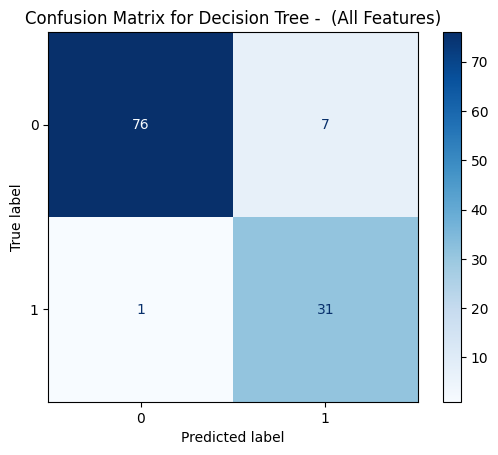

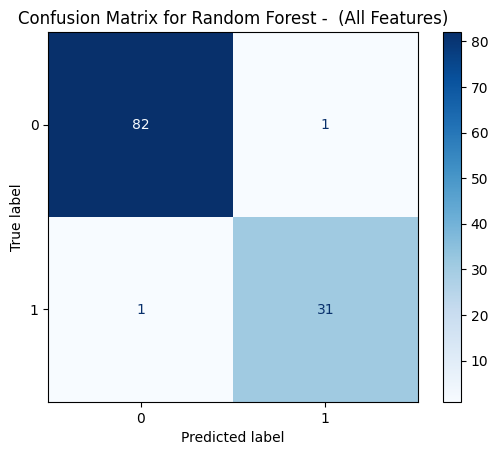

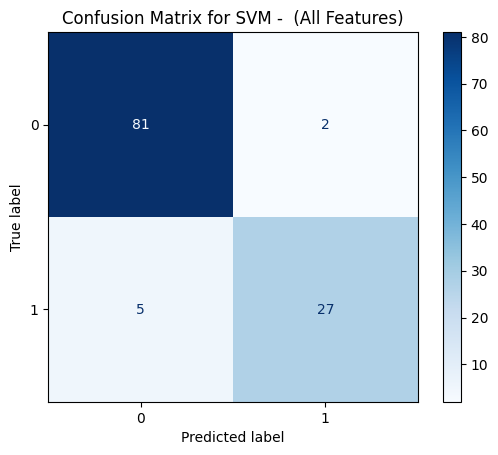

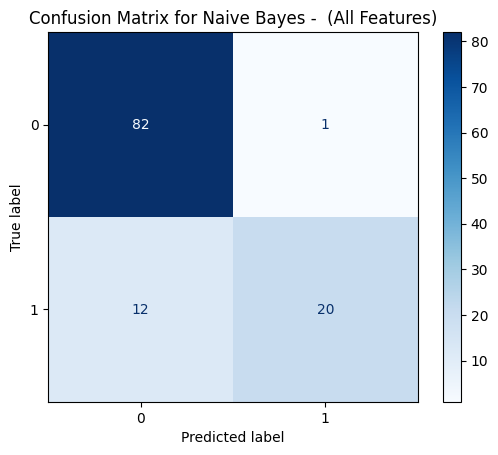





Model Performance Summary:
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.921739   0.921135  0.921739  0.921352
1                  KNN  0.921739   0.921977  0.921739  0.919567
2        Decision Tree  0.930435   0.939368  0.930435  0.932112
3        Random Forest  0.982609   0.982609  0.982609  0.982609
4                  SVM  0.939130   0.938848  0.939130  0.938174
5          Naive Bayes  0.886957   0.894613  0.886957  0.878738

Running ACO Feature Selection...
Iteration 1 | Best Accuracy: 0.9826 | Selected Features: 9
Iteration 2 | Best Accuracy: 0.9826 | Selected Features: 9
Early stopping due to stagnation.

Selected Features:
['Age', 'Physical Examination', 'Adenopathy', 'Pathology', 'Risk', 'T', 'N', 'Stage', 'Response']
Best Accuracy with Selected Features: 0.9826

Evaluating models with selected features...

📊 Model Evaluation for  (ACO Features)


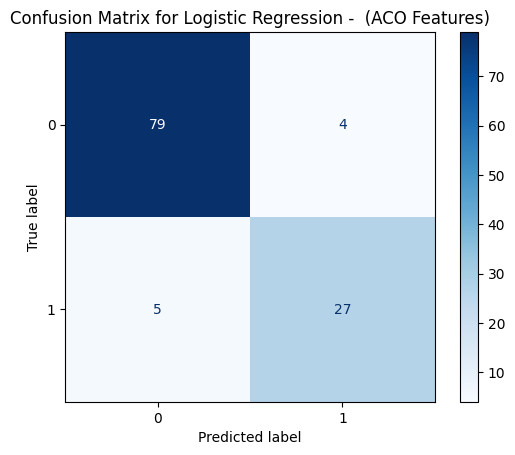

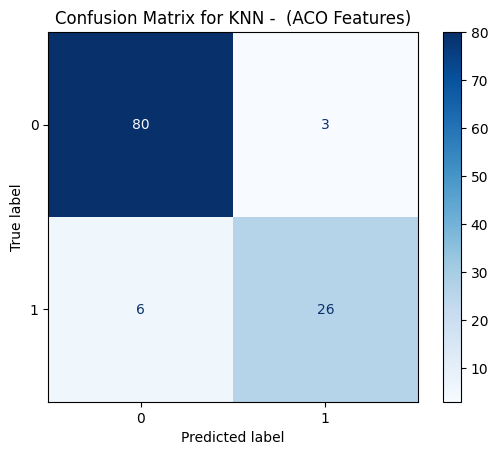

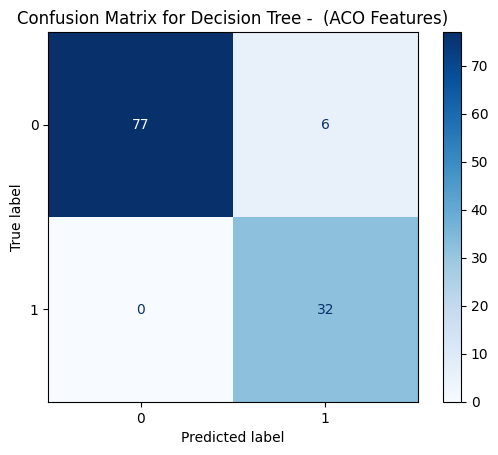

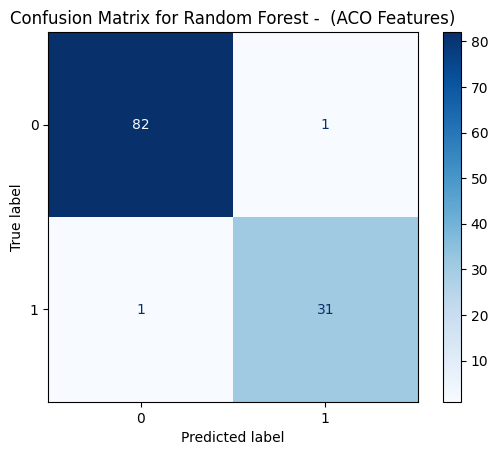

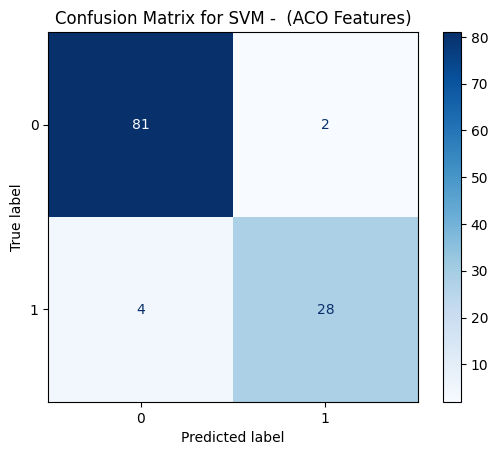

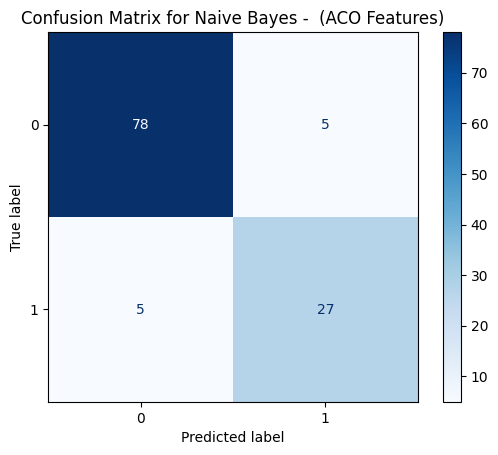





Model Performance Summary:
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.921739   0.921135  0.921739  0.921352
1                  KNN  0.921739   0.920860  0.921739  0.920509
2        Decision Tree  0.947826   0.956064  0.947826  0.949084
3        Random Forest  0.982609   0.982609  0.982609  0.982609
4                  SVM  0.947826   0.947485  0.947826  0.947295
5          Naive Bayes  0.913043   0.913043  0.913043  0.913043


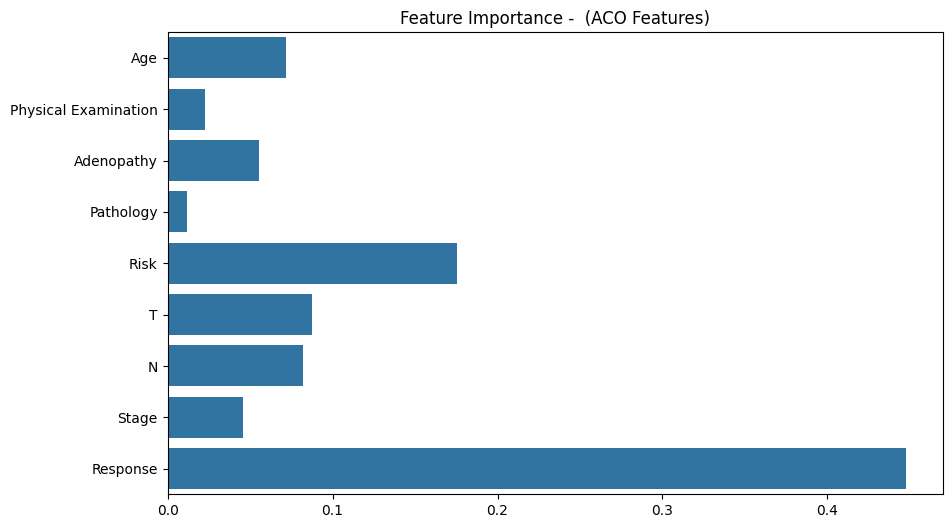

In [ ]:
thyroid_data = load_csv_as_sklearn(
    csv_path="/content/Thyroid_Diff.csv"
)
run_feature_selection_pipeline(thyroid_data)